In [1]:
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [16]:
CSV_PATH = Path('/Users/mehmetbagdinli/Desktop/deprem/outputs/analytic_with_scores.csv')
OUT_DIR  = Path('/Users/mehmetbagdinli/Desktop/deprem/outputs/figures')
MODEL    =  'distilbert'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
FRAMES = ["technical", "political", "development", "sustainability"]
FRAME_LABELS = {"technical":"Technical","political":"Political",
                "development":"Development","sustainability":"Sustainability"}
PERIOD_ORDER = ["1_post_quake","2_pres_campaign","3_inter_election",
                "4_local_campaign","5_post_local"]
PERIOD_LABELS = {
    "1_post_quake":"Post-quake\n(Feb–Apr 2023)",
    "2_pres_campaign":"Pres. campaign\n(May 2023)",
    "3_inter_election":"Inter-election\n(Jun 2023–Jan 2024)",
    "4_local_campaign":"Local campaign\n(Feb–Mar 2024)",
    "5_post_local":"Post-local\n(Apr–Dec 2024)",
}
ELECTIONS = [("2023-05-14","Pres. 1st round"),
             ("2023-05-28","Pres. runoff"),
             ("2024-03-31","Local elections")]
QUAKE_DATE = "2023-02-06"
FRAME_COLORS = {"technical":"#1f77b4","political":"#d62728",
                "development":"#2ca02c","sustainability":"#9467bd"}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"

In [18]:
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
if MODEL == "distilbert":
    for f in FRAMES:
        df[f"score_{f}"] = df[f"distilbert_score_{f}_0to3"]
else:
    for f in FRAMES:
        df[f"score_{f}"] = df[f"tfidf_score_{f}"]
print(f"{len(df)} docs, {df['date'].min().date()} - {df['date'].max().date()}")

def add_election_lines(ax, label_y_frac=0.95, color="#666666"):
    yloc = ax.get_ylim()
    label_y = yloc[0] + label_y_frac*(yloc[1]-yloc[0])
    qd = pd.to_datetime(QUAKE_DATE)
    ax.axvline(qd, color="#cc0000", linestyle=":", linewidth=1.4, alpha=0.6)
    ax.text(qd, label_y, " Earthquake", color="#cc0000", fontsize=8,
            ha="left", va="top", rotation=90, alpha=0.85)
    for date_str, name in ELECTIONS:
        d = pd.to_datetime(date_str)
        ax.axvline(d, color=color, linestyle="--", linewidth=1.0, alpha=0.6)
        ax.text(d, label_y, f" {name}", color=color, fontsize=8,
                ha="left", va="top", rotation=90, alpha=0.85)

2139 docs, 2023-02-02 - 2024-12-28


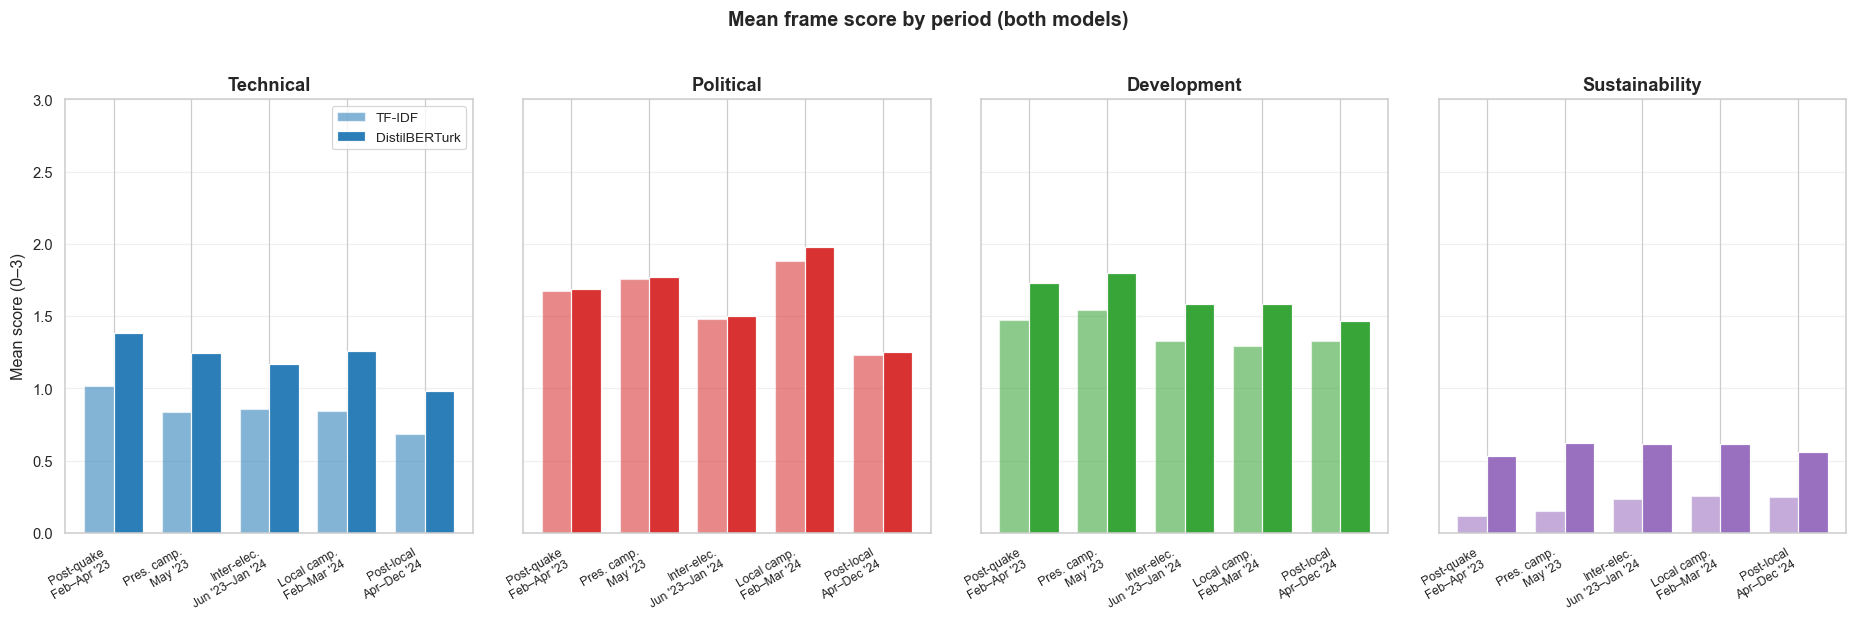

In [19]:
short_labels = {"1_post_quake":"Post-quake\nFeb–Apr '23",
                "2_pres_campaign":"Pres. camp.\nMay '23",
                "3_inter_election":"Inter-elec.\nJun '23–Jan '24",
                "4_local_campaign":"Local camp.\nFeb–Mar '24",
                "5_post_local":"Post-local\nApr–Dec '24"}
fig, axes = plt.subplots(1, 4, figsize=(17, 5.5), sharey=True)
for ax, frame in zip(axes, FRAMES):
    rows = []
    for p in PERIOD_ORDER:
        sub = df[df["period"] == p]
        rows.append({"period": short_labels[p],
                     "TF-IDF": sub[f"tfidf_score_{frame}"].mean(),
                     "DistilBERTurk": sub[f"distilbert_score_{frame}_0to3"].mean()})
    pd_df = pd.DataFrame(rows)
    x = np.arange(len(pd_df)); w = 0.38
    ax.bar(x - w/2, pd_df["TF-IDF"], w, label="TF-IDF",
           color=FRAME_COLORS[frame], alpha=0.55, edgecolor="white")
    ax.bar(x + w/2, pd_df["DistilBERTurk"], w, label="DistilBERTurk",
           color=FRAME_COLORS[frame], alpha=0.95, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(pd_df["period"], rotation=30, ha="right", fontsize=8)
    ax.set_title(FRAME_LABELS[frame], fontsize=12, weight="bold")
    ax.set_ylim(0, 3); ax.grid(axis="y", alpha=0.3)
    ax.set_ylabel("Mean score (0–3)" if frame == "technical" else "")
    if frame == "technical":
        ax.legend(loc="upper right", fontsize=9, frameon=True)
fig.suptitle("Mean frame score by period (both models)", fontsize=13, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "1_period_means_bars.png")
plt.show()

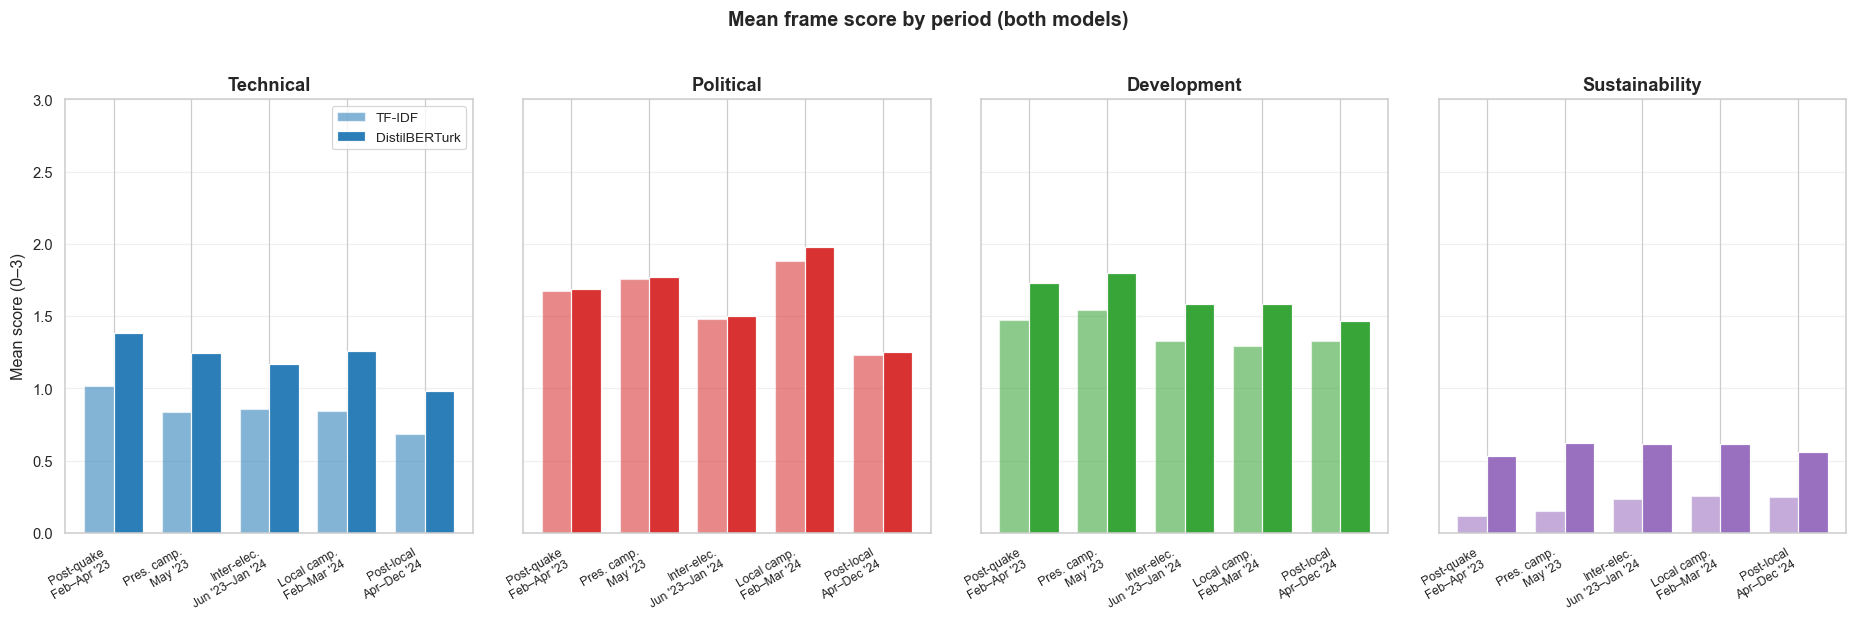

In [20]:
short_labels = {"1_post_quake":"Post-quake\nFeb–Apr '23",
                "2_pres_campaign":"Pres. camp.\nMay '23",
                "3_inter_election":"Inter-elec.\nJun '23–Jan '24",
                "4_local_campaign":"Local camp.\nFeb–Mar '24",
                "5_post_local":"Post-local\nApr–Dec '24"}
fig, axes = plt.subplots(1, 4, figsize=(17, 5.5), sharey=True)
for ax, frame in zip(axes, FRAMES):
    rows = []
    for p in PERIOD_ORDER:
        sub = df[df["period"] == p]
        rows.append({"period": short_labels[p],
                     "TF-IDF": sub[f"tfidf_score_{frame}"].mean(),
                     "DistilBERTurk": sub[f"distilbert_score_{frame}_0to3"].mean()})
    pd_df = pd.DataFrame(rows)
    x = np.arange(len(pd_df)); w = 0.38
    ax.bar(x - w/2, pd_df["TF-IDF"], w, label="TF-IDF",
           color=FRAME_COLORS[frame], alpha=0.55, edgecolor="white")
    ax.bar(x + w/2, pd_df["DistilBERTurk"], w, label="DistilBERTurk",
           color=FRAME_COLORS[frame], alpha=0.95, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(pd_df["period"], rotation=30, ha="right", fontsize=8)
    ax.set_title(FRAME_LABELS[frame], fontsize=12, weight="bold")
    ax.set_ylim(0, 3); ax.grid(axis="y", alpha=0.3)
    ax.set_ylabel("Mean score (0–3)" if frame == "technical" else "")
    if frame == "technical":
        ax.legend(loc="upper right", fontsize=9, frameon=True)
fig.suptitle("Mean frame score by period (both models)", fontsize=13, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "1_period_means_bars.png")
plt.show()

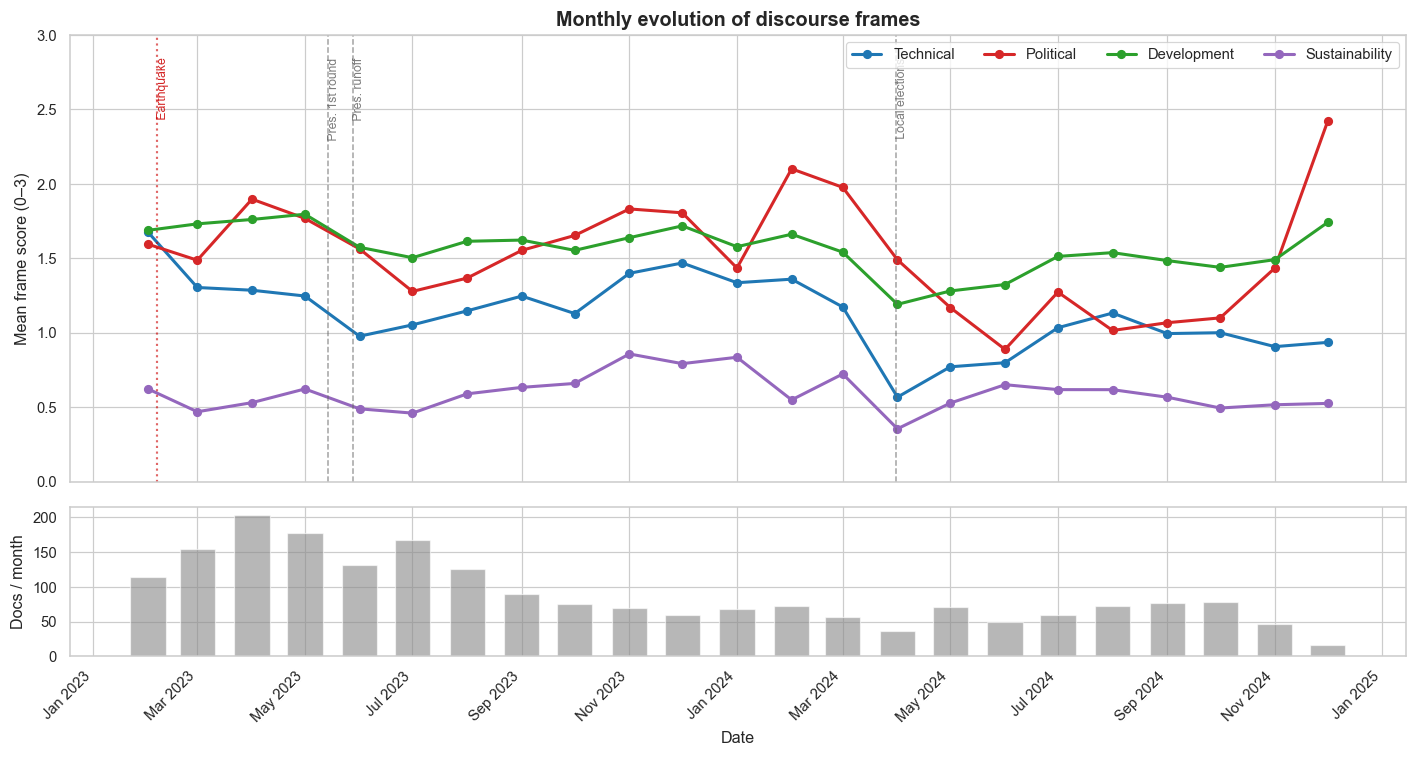

In [21]:
monthly = df.groupby("month")[[f"score_{f}" for f in FRAMES]].mean()
counts = df.groupby("month").size()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={"height_ratios":[3, 1]})
for f in FRAMES:
    ax1.plot(monthly.index, monthly[f"score_{f}"], marker="o", markersize=5,
             linewidth=2, label=FRAME_LABELS[f], color=FRAME_COLORS[f])
ax1.set_ylabel("Mean frame score (0–3)")
ax1.set_ylim(0, 3)
ax1.set_title("Monthly evolution of discourse frames", fontsize=13, weight="bold")
ax1.legend(loc="upper right", ncol=4, frameon=True)
add_election_lines(ax1)
ax2.bar(counts.index, counts.values, width=20, color="#888888", alpha=0.6)
ax2.set_ylabel("Docs / month"); ax2.set_xlabel("Date")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
fig.savefig(OUT_DIR / "2_timeseries_monthly.png")
plt.show()


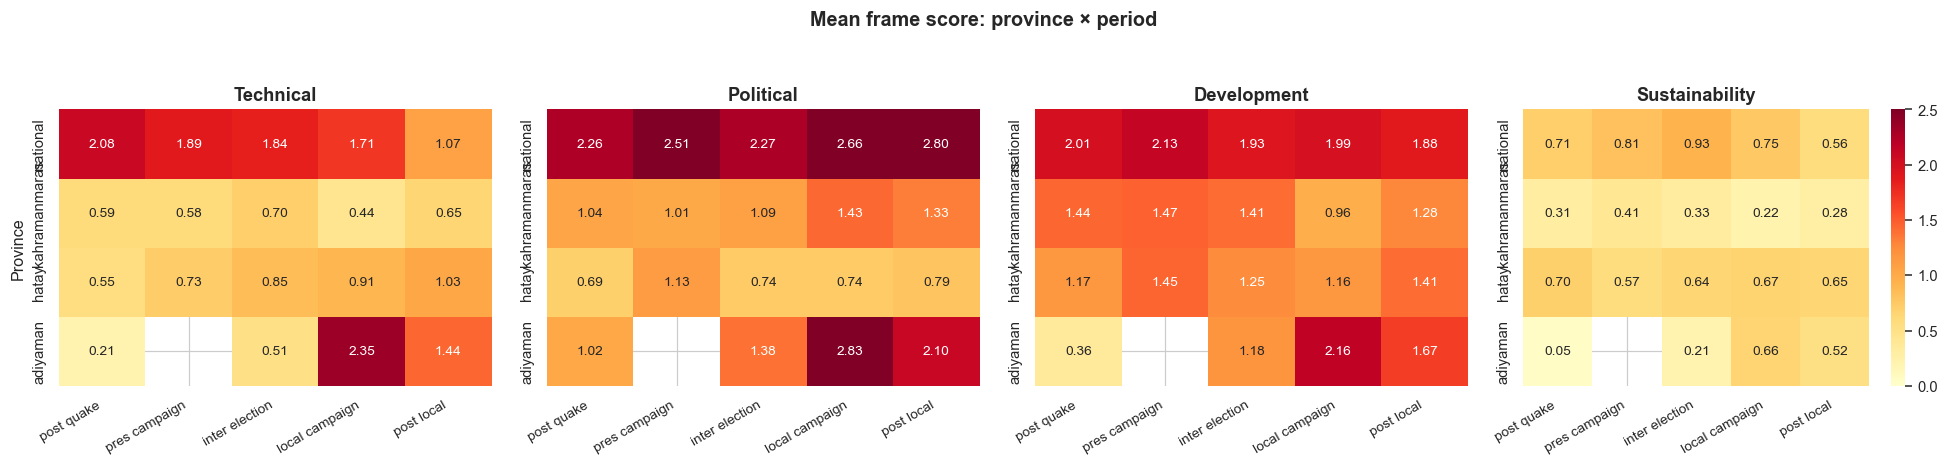

In [22]:
province_order = ["national","kahramanmaras","hatay","adiyaman"]
province_order = [p for p in province_order if p in df["province"].unique()]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, frame in zip(axes, FRAMES):
    pivot = df.pivot_table(index="province", columns="period",
                            values=f"score_{frame}", aggfunc="mean"
                           ).reindex(index=province_order, columns=PERIOD_ORDER)
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".2f", cmap="YlOrRd",
                vmin=0, vmax=2.5, cbar=ax is axes[-1], annot_kws={"size":9})
    ax.set_title(FRAME_LABELS[frame], fontsize=12, weight="bold")
    ax.set_xlabel(""); ax.set_ylabel("Province" if ax is axes[0] else "")
    ax.set_xticklabels([p.split("_",1)[1].replace("_"," ") for p in PERIOD_ORDER],
                        rotation=30, ha="right", fontsize=9)
fig.suptitle("Mean frame score: province × period", fontsize=13, weight="bold", y=1.05)
fig.tight_layout()
fig.savefig(OUT_DIR / "3_province_period_heatmap.png")
plt.show()

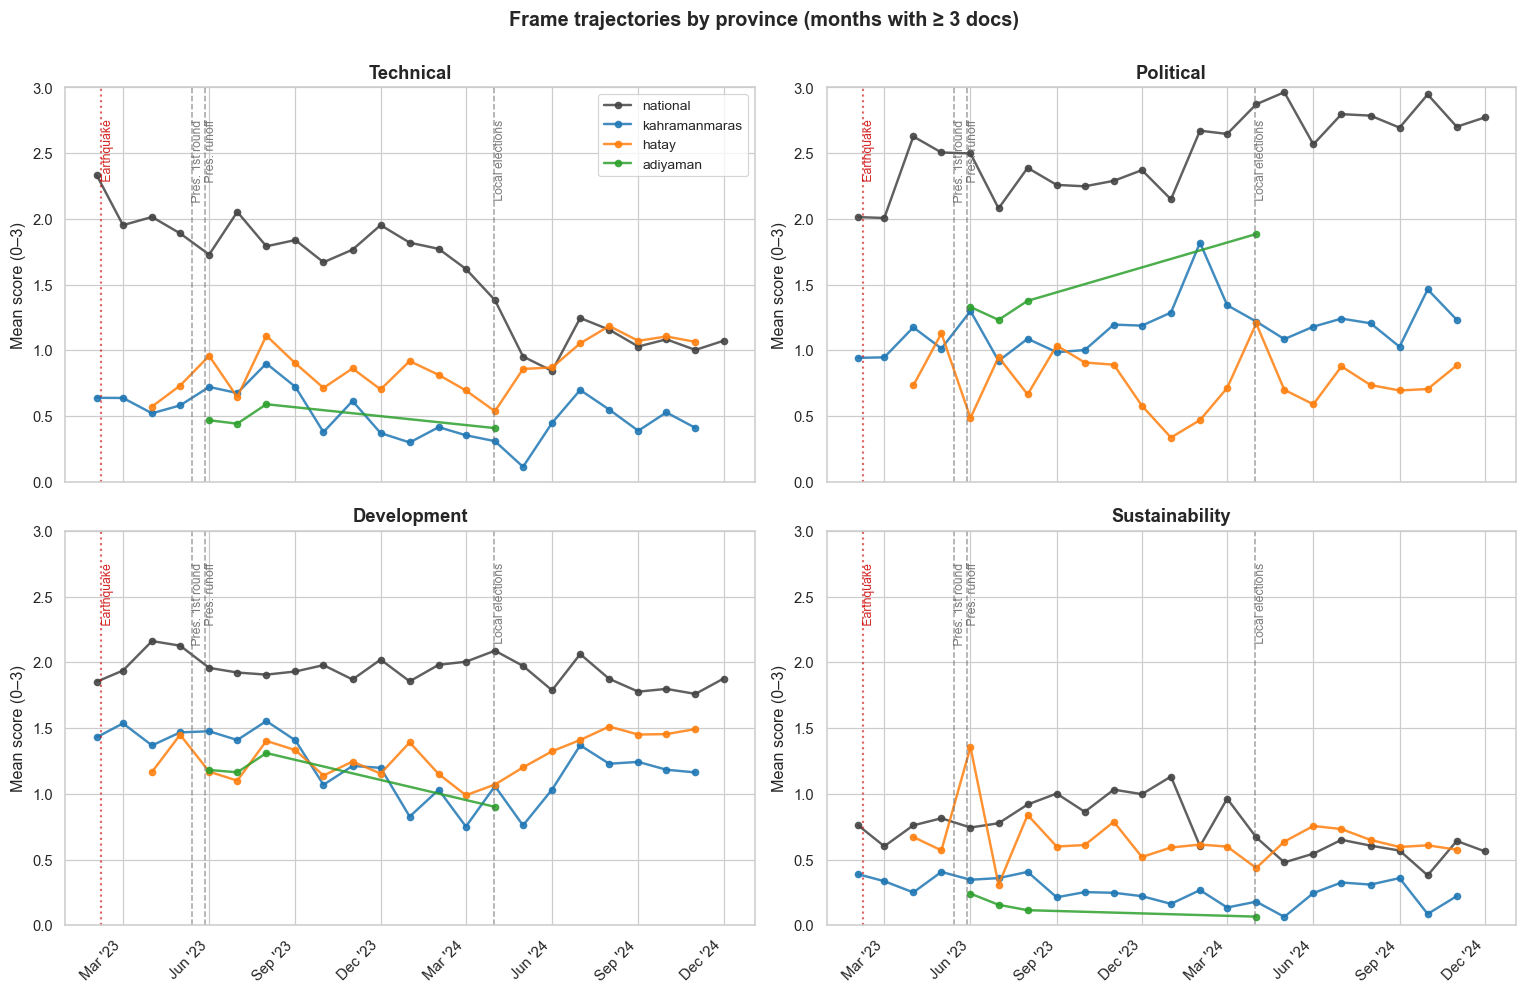

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()
province_colors = {"national":"#444444","kahramanmaras":"#1f77b4",
                    "hatay":"#ff7f0e","adiyaman":"#2ca02c"}
for ax, frame in zip(axes, FRAMES):
    for prov in province_order:
        sub = df[df["province"] == prov]
        grp = sub.groupby("month")[f"score_{frame}"].agg(["mean","count"])
        grp = grp[grp["count"] >= 3]
        if len(grp) == 0: continue
        ax.plot(grp.index, grp["mean"], marker="o", markersize=4,
                linewidth=1.6, alpha=0.85, label=prov,
                color=province_colors.get(prov))
    ax.set_title(FRAME_LABELS[frame], fontsize=12, weight="bold")
    ax.set_ylim(0, 3); ax.set_ylabel("Mean score (0–3)")
    add_election_lines(ax, label_y_frac=0.92)
    if frame == "technical": ax.legend(loc="upper right", fontsize=9)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.suptitle("Frame trajectories by province (months with ≥ 3 docs)",
             fontsize=13, weight="bold", y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / "4_province_timeseries.png")
plt.show()

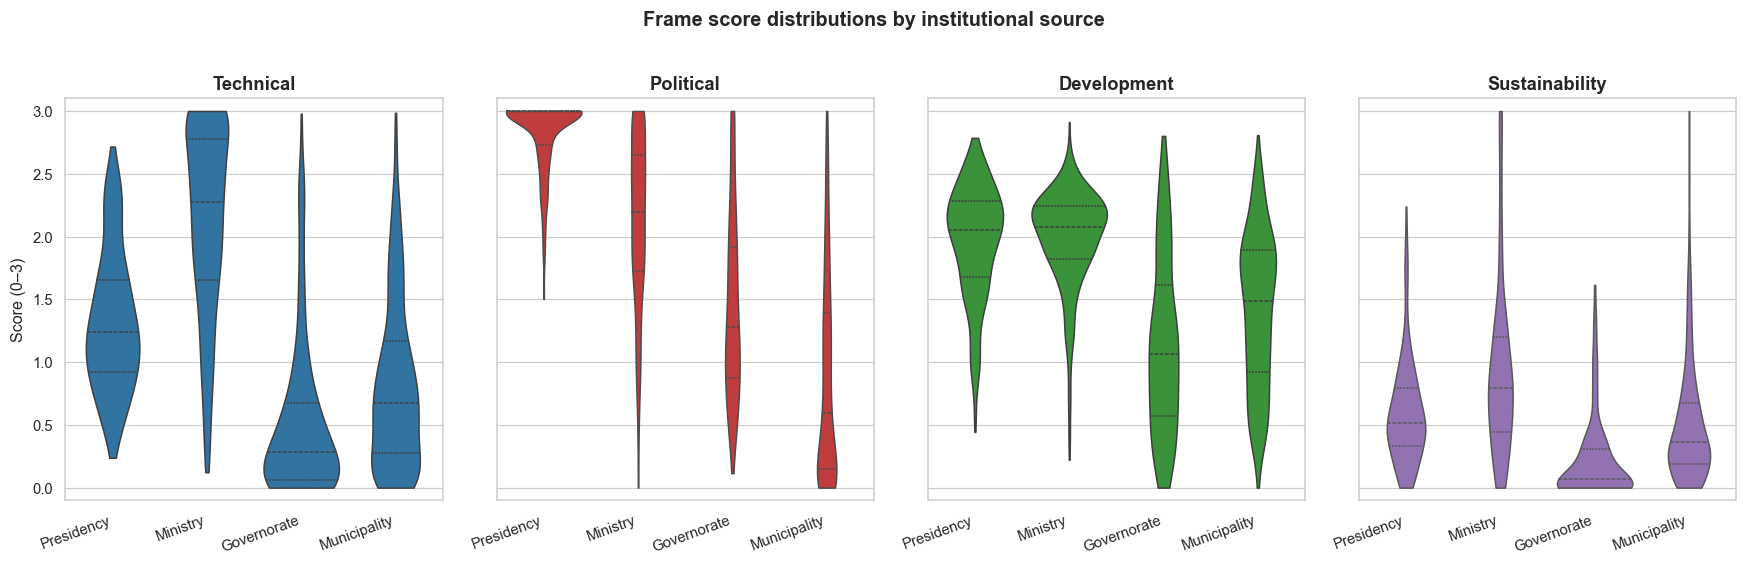

In [24]:
src = df.copy()
src["source_type"] = src["source_type"].str.lower().str.strip()
src["source_type"] = src["source_type"].replace({"bakanlık":"bakanlik"})
keep = src["source_type"].value_counts()
keep = keep[keep >= 30].index
src = src[src["source_type"].isin(keep)]
src_order = ["cumhurbaskanligi","bakanlik","valilik","belediye"]
src_order = [s for s in src_order if s in keep]
src_labels = {"cumhurbaskanligi":"Presidency","bakanlik":"Ministry",
              "valilik":"Governorate","belediye":"Municipality"}
long = src.melt(id_vars=["source_type"],
                value_vars=[f"score_{f}" for f in FRAMES],
                var_name="frame", value_name="score")
long["frame"] = long["frame"].str.replace("score_","")
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, frame in zip(axes, FRAMES):
    sub = long[long["frame"] == frame]
    sns.violinplot(data=sub, x="source_type", y="score", ax=ax,
                   order=src_order, color=FRAME_COLORS[frame],
                   inner="quartile", cut=0, linewidth=1)
    ax.set_xticks(range(len(src_order)))
    ax.set_xticklabels([src_labels[s] for s in src_order], rotation=20, ha="right")
    ax.set_xlabel(""); ax.set_ylim(-0.1, 3.1)
    ax.set_ylabel("Score (0–3)" if ax is axes[0] else "")
    ax.set_title(FRAME_LABELS[frame], fontsize=12, weight="bold")
fig.suptitle("Frame score distributions by institutional source",
             fontsize=13, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "5_source_type_violins.png")
plt.show()

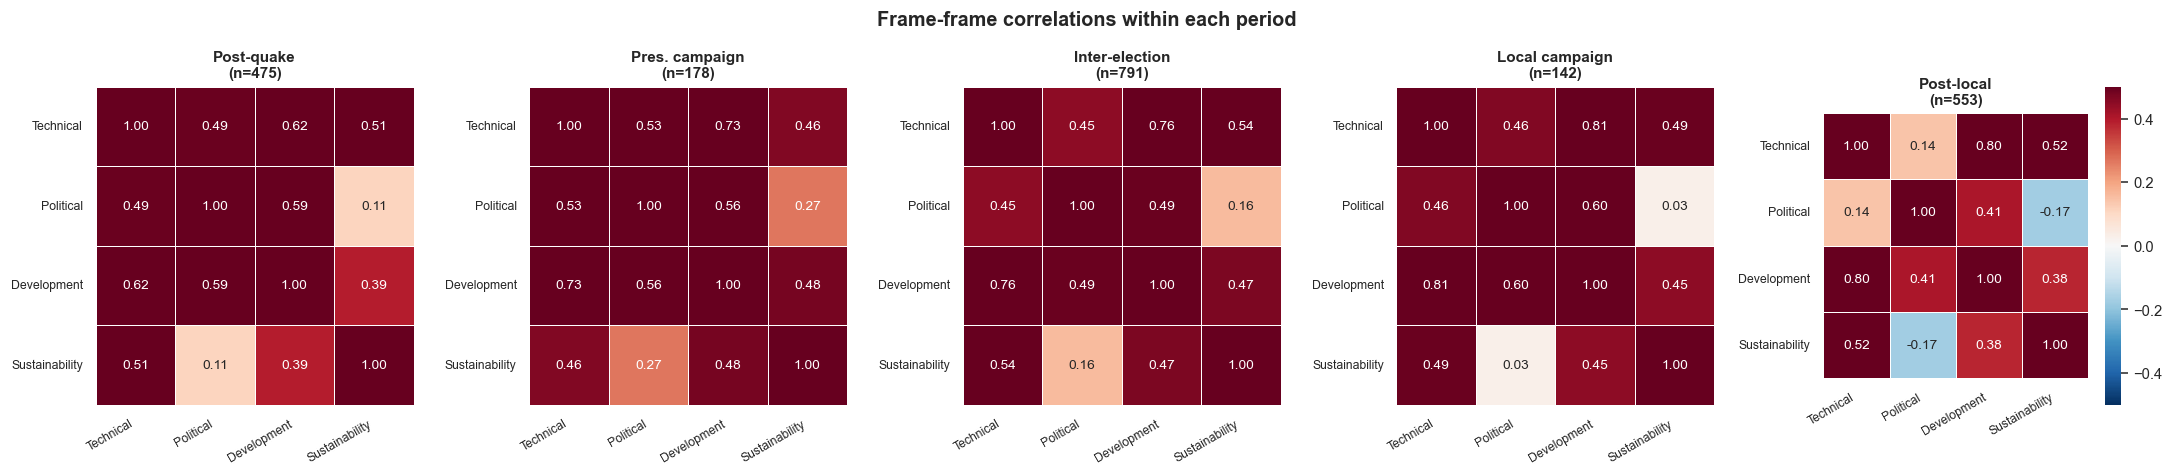

In [25]:
fig, axes = plt.subplots(1, len(PERIOD_ORDER), figsize=(20, 4))
score_cols = [f"score_{f}" for f in FRAMES]
short = [FRAME_LABELS[f] for f in FRAMES]
for ax, p in zip(axes, PERIOD_ORDER):
    sub = df[df["period"] == p]
    corr = sub[score_cols].corr()
    corr.index = short; corr.columns = short
    sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, vmin=-0.5, vmax=0.5, cbar=ax is axes[-1],
                annot_kws={"size":9}, square=True, linewidths=0.5,
                xticklabels=short, yticklabels=short)
    title_short = PERIOD_LABELS[p].split("\n")[0]
    ax.set_title(f"{title_short}\n(n={len(sub)})", fontsize=10, weight="bold")
    ax.set_xticklabels(short, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(short, rotation=0, fontsize=8)
fig.suptitle("Frame-frame correlations within each period",
             fontsize=13, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "6_frame_correlations.png")
plt.show()


In [26]:
print("\n=== Period × frame mean scores ===")
means = df.groupby("period")[[f"score_{f}" for f in FRAMES]].mean().reindex(PERIOD_ORDER)
means.columns = [FRAME_LABELS[f] for f in FRAMES]
print(means.round(3).to_string())

print("\n=== Province × frame mean scores ===")
pmeans = df.groupby("province")[[f"score_{f}" for f in FRAMES]].mean()
pmeans.columns = [FRAME_LABELS[f] for f in FRAMES]
print(pmeans.round(3).to_string())

print(f"\nFigürler kaydedildi: {OUT_DIR}")


=== Period × frame mean scores ===
                  Technical  Political  Development  Sustainability
period                                                             
1_post_quake          1.380      1.685        1.727           0.531
2_pres_campaign       1.247      1.768        1.796           0.622
3_inter_election      1.165      1.501        1.580           0.614
4_local_campaign      1.257      1.979        1.584           0.616
5_post_local          0.981      1.254        1.467           0.562

=== Province × frame mean scores ===
               Technical  Political  Development  Sustainability
province                                                        
adiyaman           0.919      1.687        1.340           0.336
hatay              0.961      0.784        1.351           0.645
kahramanmaras      0.640      1.115        1.387           0.322
national           1.825      2.389        1.976           0.794

Figürler kaydedildi: /Users/mehmetbagdinli/Desktop/deprem/o

2139 docs, 2023-02-02 - 2024-12-28


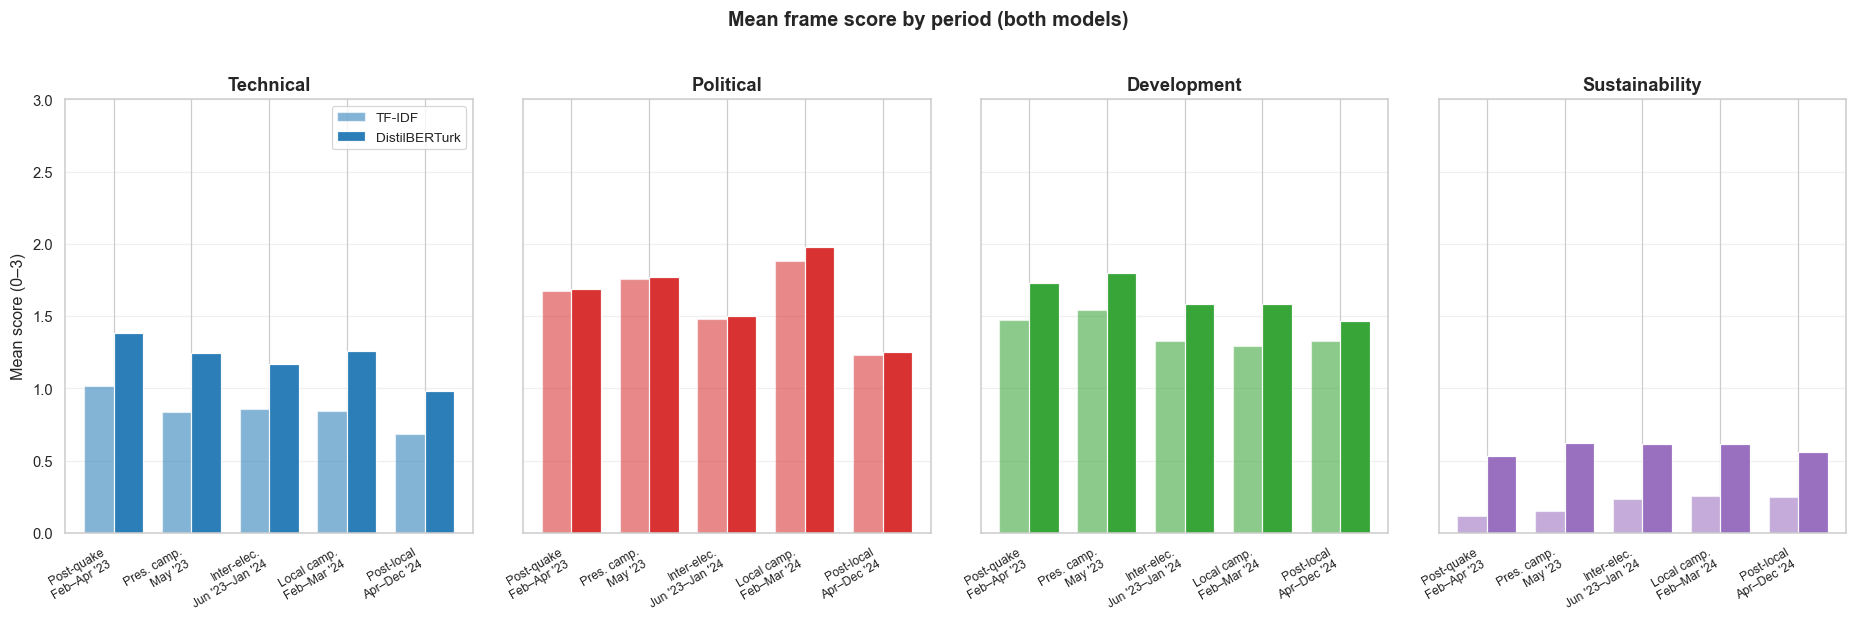

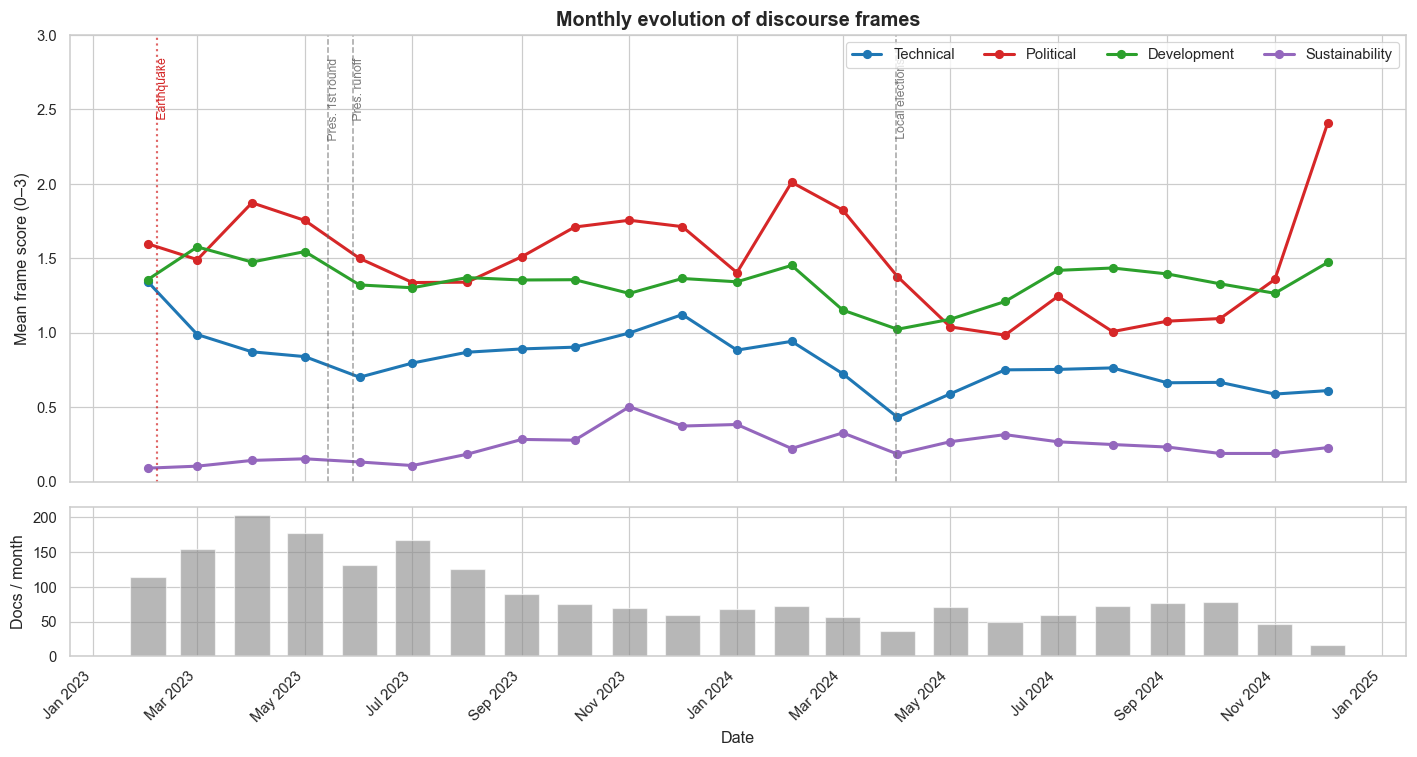

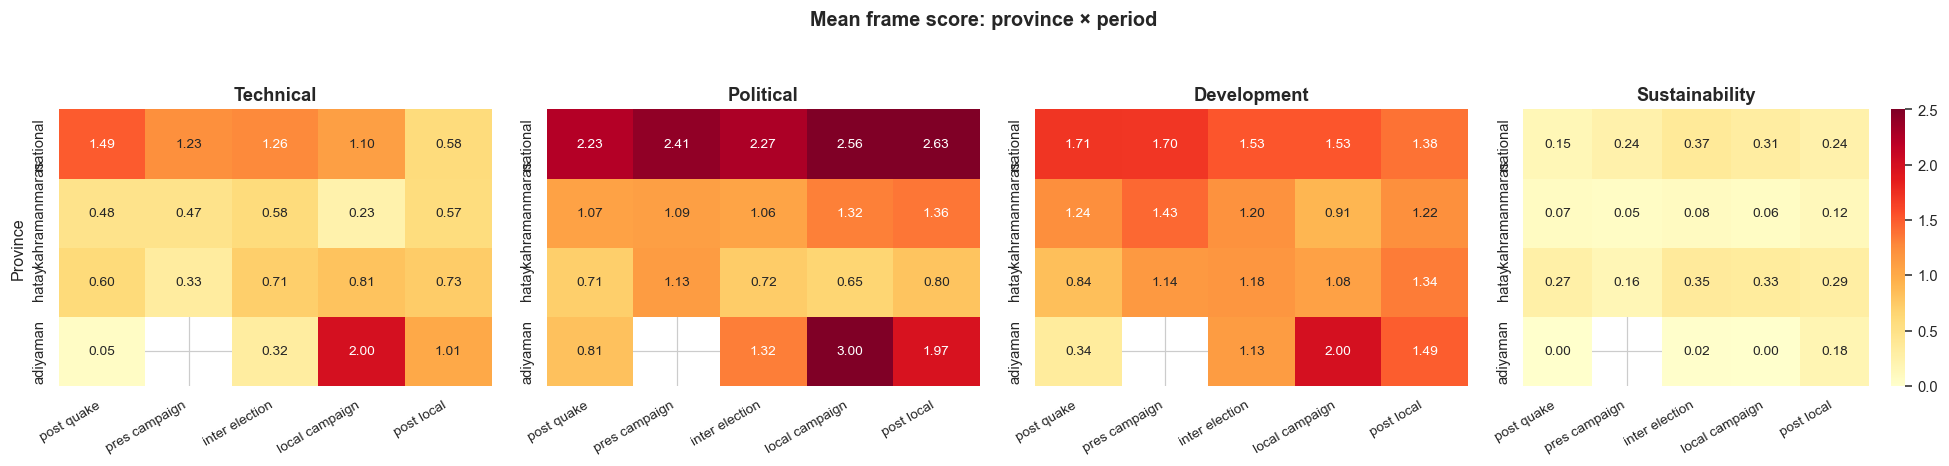

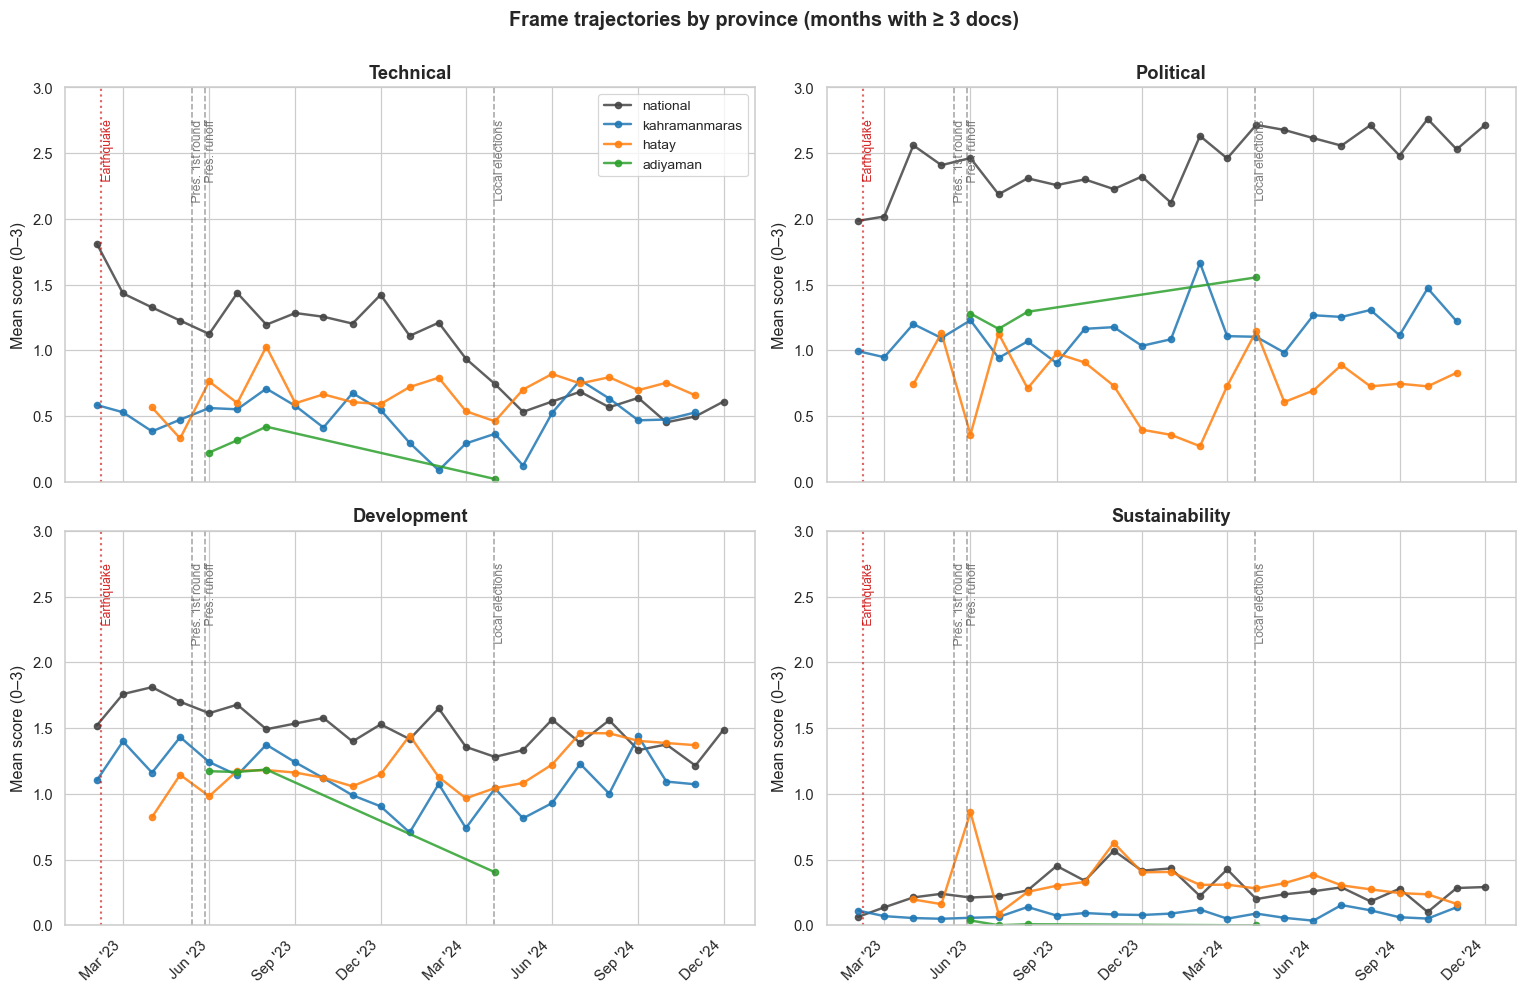

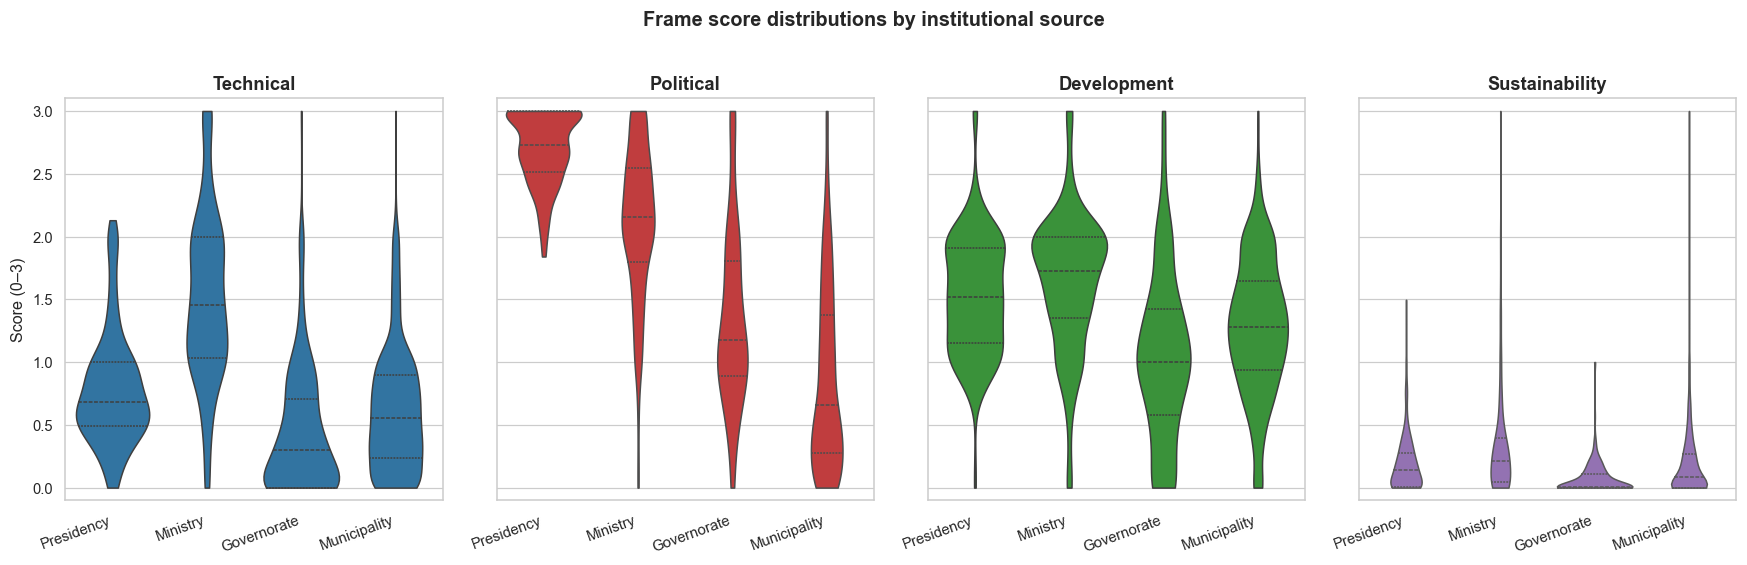

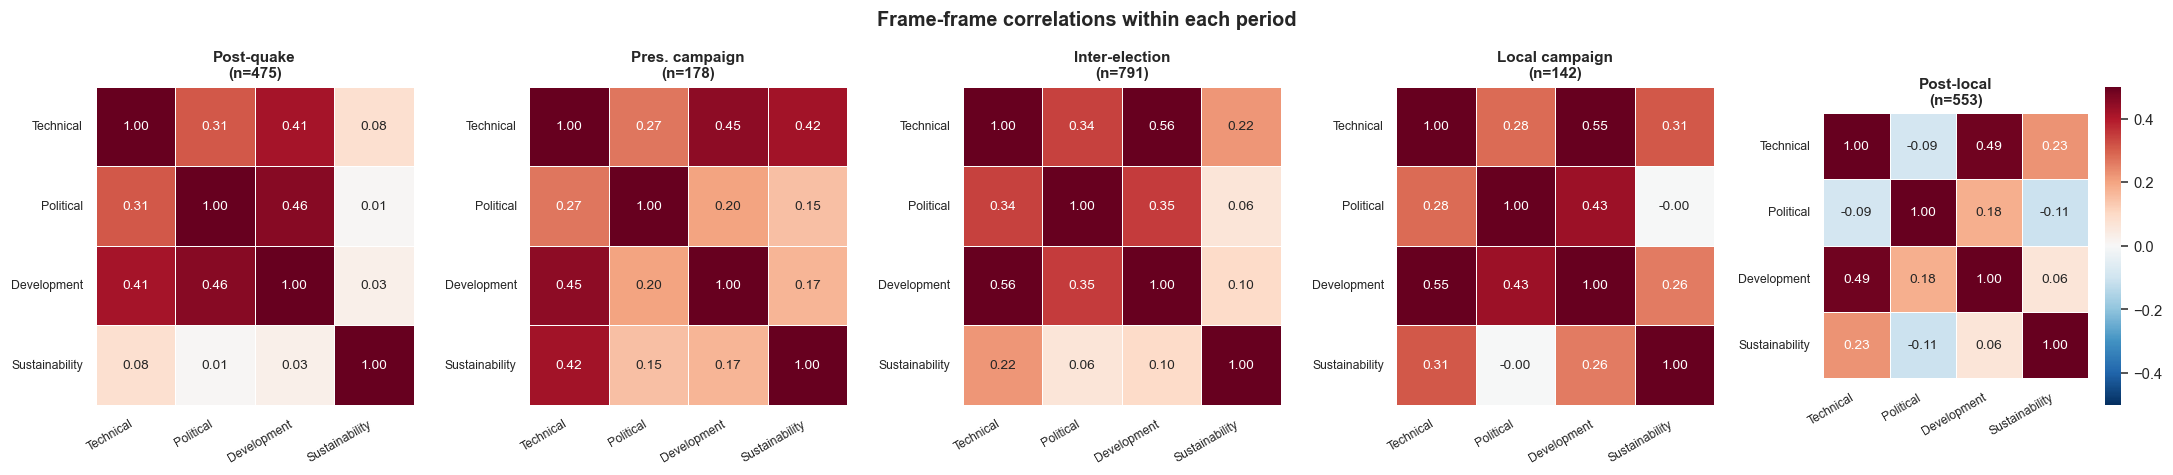


=== Period × frame mean scores ===
                  Technical  Political  Development  Sustainability
period                                                             
1_post_quake          1.019      1.676        1.474           0.116
2_pres_campaign       0.839      1.754        1.545           0.153
3_inter_election      0.860      1.482        1.326           0.237
4_local_campaign      0.846      1.880        1.296           0.256
5_post_local          0.685      1.230        1.329           0.250

=== Province × frame mean scores ===
               Technical  Political  Development  Sustainability
province                                                        
adiyaman           0.625      1.590        1.234           0.085
hatay              0.714      0.777        1.269           0.307
kahramanmaras      0.523      1.117        1.225           0.081
national           1.242      2.338        1.590           0.266

Figürler kaydedildi: /Users/mehmetbagdinli/Desktop/deprem/o

In [28]:
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

CSV_PATH = Path('/Users/mehmetbagdinli/Desktop/deprem/outputs/analytic_with_scores.csv')
OUT_DIR  = Path('/Users/mehmetbagdinli/Desktop/deprem/outputs/figures_tfidf')
MODEL    = 'tfidf'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FRAMES = ["technical", "political", "development", "sustainability"]
FRAME_LABELS = {"technical":"Technical","political":"Political",
                "development":"Development","sustainability":"Sustainability"}
PERIOD_ORDER = ["1_post_quake","2_pres_campaign","3_inter_election",
                "4_local_campaign","5_post_local"]
PERIOD_LABELS = {
    "1_post_quake":"Post-quake\n(Feb–Apr 2023)",
    "2_pres_campaign":"Pres. campaign\n(May 2023)",
    "3_inter_election":"Inter-election\n(Jun 2023–Jan 2024)",
    "4_local_campaign":"Local campaign\n(Feb–Mar 2024)",
    "5_post_local":"Post-local\n(Apr–Dec 2024)",
}
ELECTIONS = [("2023-05-14","Pres. 1st round"),
             ("2023-05-28","Pres. runoff"),
             ("2024-03-31","Local elections")]
QUAKE_DATE = "2023-02-06"
FRAME_COLORS = {"technical":"#1f77b4","political":"#d62728",
                "development":"#2ca02c","sustainability":"#9467bd"}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"

df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
if MODEL == "distilbert":
    for f in FRAMES:
        df[f"score_{f}"] = df[f"distilbert_score_{f}_0to3"]
else:
    for f in FRAMES:
        df[f"score_{f}"] = df[f"tfidf_score_{f}"]
print(f"{len(df)} docs, {df['date'].min().date()} - {df['date'].max().date()}")

def add_election_lines(ax, label_y_frac=0.95, color="#666666"):
    yloc = ax.get_ylim()
    label_y = yloc[0] + label_y_frac*(yloc[1]-yloc[0])
    qd = pd.to_datetime(QUAKE_DATE)
    ax.axvline(qd, color="#cc0000", linestyle=":", linewidth=1.4, alpha=0.6)
    ax.text(qd, label_y, " Earthquake", color="#cc0000", fontsize=8,
            ha="left", va="top", rotation=90, alpha=0.85)
    for date_str, name in ELECTIONS:
        d = pd.to_datetime(date_str)
        ax.axvline(d, color=color, linestyle="--", linewidth=1.0, alpha=0.6)
        ax.text(d, label_y, f" {name}", color=color, fontsize=8,
                ha="left", va="top", rotation=90, alpha=0.85)

short_labels = {"1_post_quake":"Post-quake\nFeb–Apr '23",
                "2_pres_campaign":"Pres. camp.\nMay '23",
                "3_inter_election":"Inter-elec.\nJun '23–Jan '24",
                "4_local_campaign":"Local camp.\nFeb–Mar '24",
                "5_post_local":"Post-local\nApr–Dec '24"}
fig, axes = plt.subplots(1, 4, figsize=(17, 5.5), sharey=True)
for ax, frame in zip(axes, FRAMES):
    rows = []
    for p in PERIOD_ORDER:
        sub = df[df["period"] == p]
        rows.append({"period": short_labels[p],
                     "TF-IDF": sub[f"tfidf_score_{frame}"].mean(),
                     "DistilBERTurk": sub[f"distilbert_score_{frame}_0to3"].mean()})
    pd_df = pd.DataFrame(rows)
    x = np.arange(len(pd_df)); w = 0.38
    ax.bar(x - w/2, pd_df["TF-IDF"], w, label="TF-IDF",
           color=FRAME_COLORS[frame], alpha=0.55, edgecolor="white")
    ax.bar(x + w/2, pd_df["DistilBERTurk"], w, label="DistilBERTurk",
           color=FRAME_COLORS[frame], alpha=0.95, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(pd_df["period"], rotation=30, ha="right", fontsize=8)
    ax.set_title(FRAME_LABELS[frame], fontsize=12, weight="bold")
    ax.set_ylim(0, 3); ax.grid(axis="y", alpha=0.3)
    ax.set_ylabel("Mean score (0–3)" if frame == "technical" else "")
    if frame == "technical":
        ax.legend(loc="upper right", fontsize=9, frameon=True)
fig.suptitle("Mean frame score by period (both models)", fontsize=13, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "1_period_means_bars.png")
plt.show()

monthly = df.groupby("month")[[f"score_{f}" for f in FRAMES]].mean()
counts = df.groupby("month").size()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={"height_ratios":[3, 1]})
for f in FRAMES:
    ax1.plot(monthly.index, monthly[f"score_{f}"], marker="o", markersize=5,
             linewidth=2, label=FRAME_LABELS[f], color=FRAME_COLORS[f])
ax1.set_ylabel("Mean frame score (0–3)")
ax1.set_ylim(0, 3)
ax1.set_title("Monthly evolution of discourse frames", fontsize=13, weight="bold")
ax1.legend(loc="upper right", ncol=4, frameon=True)
add_election_lines(ax1)
ax2.bar(counts.index, counts.values, width=20, color="#888888", alpha=0.6)
ax2.set_ylabel("Docs / month"); ax2.set_xlabel("Date")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")
fig.tight_layout()
fig.savefig(OUT_DIR / "2_timeseries_monthly.png")
plt.show()

province_order = ["national","kahramanmaras","hatay","adiyaman"]
province_order = [p for p in province_order if p in df["province"].unique()]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, frame in zip(axes, FRAMES):
    pivot = df.pivot_table(index="province", columns="period",
                            values=f"score_{frame}", aggfunc="mean"
                           ).reindex(index=province_order, columns=PERIOD_ORDER)
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".2f", cmap="YlOrRd",
                vmin=0, vmax=2.5, cbar=ax is axes[-1], annot_kws={"size":9})
    ax.set_title(FRAME_LABELS[frame], fontsize=12, weight="bold")
    ax.set_xlabel(""); ax.set_ylabel("Province" if ax is axes[0] else "")
    ax.set_xticklabels([p.split("_",1)[1].replace("_"," ") for p in PERIOD_ORDER],
                        rotation=30, ha="right", fontsize=9)
fig.suptitle("Mean frame score: province × period", fontsize=13, weight="bold", y=1.05)
fig.tight_layout()
fig.savefig(OUT_DIR / "3_province_period_heatmap.png")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
axes = axes.flatten()
province_colors = {"national":"#444444","kahramanmaras":"#1f77b4",
                    "hatay":"#ff7f0e","adiyaman":"#2ca02c"}
for ax, frame in zip(axes, FRAMES):
    for prov in province_order:
        sub = df[df["province"] == prov]
        grp = sub.groupby("month")[f"score_{frame}"].agg(["mean","count"])
        grp = grp[grp["count"] >= 3]
        if len(grp) == 0: continue
        ax.plot(grp.index, grp["mean"], marker="o", markersize=4,
                linewidth=1.6, alpha=0.85, label=prov,
                color=province_colors.get(prov))
    ax.set_title(FRAME_LABELS[frame], fontsize=12, weight="bold")
    ax.set_ylim(0, 3); ax.set_ylabel("Mean score (0–3)")
    add_election_lines(ax, label_y_frac=0.92)
    if frame == "technical": ax.legend(loc="upper right", fontsize=9)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
fig.suptitle("Frame trajectories by province (months with ≥ 3 docs)",
             fontsize=13, weight="bold", y=1.00)
fig.tight_layout()
fig.savefig(OUT_DIR / "4_province_timeseries.png")
plt.show()

src = df.copy()
src["source_type"] = src["source_type"].str.lower().str.strip()
src["source_type"] = src["source_type"].replace({"bakanlık":"bakanlik"})
keep = src["source_type"].value_counts()
keep = keep[keep >= 30].index
src = src[src["source_type"].isin(keep)]
src_order = ["cumhurbaskanligi","bakanlik","valilik","belediye"]
src_order = [s for s in src_order if s in keep]
src_labels = {"cumhurbaskanligi":"Presidency","bakanlik":"Ministry",
              "valilik":"Governorate","belediye":"Municipality"}
long = src.melt(id_vars=["source_type"],
                value_vars=[f"score_{f}" for f in FRAMES],
                var_name="frame", value_name="score")
long["frame"] = long["frame"].str.replace("score_","")
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, frame in zip(axes, FRAMES):
    sub = long[long["frame"] == frame]
    sns.violinplot(data=sub, x="source_type", y="score", ax=ax,
                   order=src_order, color=FRAME_COLORS[frame],
                   inner="quartile", cut=0, linewidth=1)
    ax.set_xticks(range(len(src_order)))
    ax.set_xticklabels([src_labels[s] for s in src_order], rotation=20, ha="right")
    ax.set_xlabel(""); ax.set_ylim(-0.1, 3.1)
    ax.set_ylabel("Score (0–3)" if ax is axes[0] else "")
    ax.set_title(FRAME_LABELS[frame], fontsize=12, weight="bold")
fig.suptitle("Frame score distributions by institutional source",
             fontsize=13, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "5_source_type_violins.png")
plt.show()

fig, axes = plt.subplots(1, len(PERIOD_ORDER), figsize=(20, 4))
score_cols = [f"score_{f}" for f in FRAMES]
short = [FRAME_LABELS[f] for f in FRAMES]
for ax, p in zip(axes, PERIOD_ORDER):
    sub = df[df["period"] == p]
    corr = sub[score_cols].corr()
    corr.index = short; corr.columns = short
    sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, vmin=-0.5, vmax=0.5, cbar=ax is axes[-1],
                annot_kws={"size":9}, square=True, linewidths=0.5,
                xticklabels=short, yticklabels=short)
    title_short = PERIOD_LABELS[p].split("\n")[0]
    ax.set_title(f"{title_short}\n(n={len(sub)})", fontsize=10, weight="bold")
    ax.set_xticklabels(short, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(short, rotation=0, fontsize=8)
fig.suptitle("Frame-frame correlations within each period",
             fontsize=13, weight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "6_frame_correlations.png")
plt.show()

print("\n=== Period × frame mean scores ===")
means = df.groupby("period")[[f"score_{f}" for f in FRAMES]].mean().reindex(PERIOD_ORDER)
means.columns = [FRAME_LABELS[f] for f in FRAMES]
print(means.round(3).to_string())

print("\n=== Province × frame mean scores ===")
pmeans = df.groupby("province")[[f"score_{f}" for f in FRAMES]].mean()
pmeans.columns = [FRAME_LABELS[f] for f in FRAMES]
print(pmeans.round(3).to_string())

print(f"\nFigürler kaydedildi: {OUT_DIR}")

In [29]:
"""
Extended frame analysis on top of the existing 6 figures.
Runs 10 additional analyses:
  1. Model agreement (TF-IDF vs DistilBERTurk)
  2. Statistical significance tests (Kruskal-Wallis, Dunn, mixed effects)
  3. Frame dominance + clustering (k-means + PCA)
  4. Politicization index (ratio time series)
  5. Event study (±30 day windows)
  6. Log-odds with Dirichlet prior (distinctive words)
  7. Party analysis (template — verify mappings)
  8. Text length control
  9. Frame entropy (per-doc focus measure)
 10. Difference-in-differences

Each section is independent — you can comment out any block to skip it.
Outputs (figures + CSV summaries) go to OUT_DIR.
"""

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import re
from collections import Counter
from itertools import combinations

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, spearmanr, pearsonr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf


CSV_PATH = Path('/Users/mehmetbagdinli/Desktop/deprem/outputs/analytic_with_scores.csv')
OUT_DIR  = Path('/Users/mehmetbagdinli/Desktop/deprem/outputs/figures_extended')
MODEL    = 'distilbert'   # primary model: 'tfidf' or 'distilbert'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FRAMES = ["technical", "political", "development", "sustainability"]
FRAME_LABELS = {"technical":"Technical","political":"Political",
                "development":"Development","sustainability":"Sustainability"}
PERIOD_ORDER = ["1_post_quake","2_pres_campaign","3_inter_election",
                "4_local_campaign","5_post_local"]
PERIOD_LABELS_SHORT = {
    "1_post_quake":"Post-quake",
    "2_pres_campaign":"Pres. camp.",
    "3_inter_election":"Inter-elec.",
    "4_local_campaign":"Local camp.",
    "5_post_local":"Post-local",
}
FRAME_COLORS = {"technical":"#1f77b4","political":"#d62728",
                "development":"#2ca02c","sustainability":"#9467bd"}
ELECTIONS = [("2023-05-14","Pres. 1st"), ("2023-05-28","Pres. runoff"),
             ("2024-03-31","Local")]
QUAKE     = "2023-02-06"
QUAKE_ANN = "2024-02-06"

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams["figure.dpi"]   = 110
plt.rcParams["savefig.dpi"]  = 200
plt.rcParams["savefig.bbox"] = "tight"


df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df["date"]  = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
df["source_type"] = (df["source_type"].str.lower().str.strip()
                     .replace({"bakanlık":"bakanlik"}))

if MODEL == "distilbert":
    for f in FRAMES:
        df[f"score_{f}"] = df[f"distilbert_score_{f}_0to3"]
else:
    for f in FRAMES:
        df[f"score_{f}"] = df[f"tfidf_score_{f}"]
score_cols = [f"score_{f}" for f in FRAMES]

print(f"Loaded {len(df)} docs | {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Primary model = {MODEL}\n")


print("="*60); print("1. MODEL AGREEMENT"); print("="*60)

agreement_rows = []
for f in FRAMES:
    tf = df[f"tfidf_score_{f}"]
    db = df[f"distilbert_score_{f}_0to3"]
    r_p, _ = pearsonr(tf, db)
    r_s, _ = spearmanr(tf, db)
    # Bin TF-IDF to 0..3 by quantiles to compute weighted kappa
    qs = [tf.min()-0.001, tf.quantile(.40), tf.quantile(.70), tf.quantile(.90), tf.max()+0.001]
    qs = sorted(set(qs))
    if len(qs) >= 5:
        tf_bin = pd.cut(tf, bins=qs, labels=[0,1,2,3], include_lowest=True).astype(int)
    else:
        # fallback: just rank-based binning
        tf_bin = pd.qcut(tf.rank(method="first"), q=4, labels=[0,1,2,3]).astype(int)
    db_bin = db.round().clip(0,3).astype(int)
    kappa = cohen_kappa_score(tf_bin, db_bin, weights="quadratic")
    agreement_rows.append({"frame":f, "pearson":r_p, "spearman":r_s,
                           "weighted_kappa":kappa})

agr_df = pd.DataFrame(agreement_rows)
print(agr_df.round(3).to_string(index=False))
agr_df.to_csv(OUT_DIR/"01_model_agreement_stats.csv", index=False)

# Scatter per frame
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, f in zip(axes.flat, FRAMES):
    tf = df[f"tfidf_score_{f}"]; db = df[f"distilbert_score_{f}_0to3"]
    ax.scatter(tf, db, s=8, alpha=0.25, color=FRAME_COLORS[f])
    ax.plot([0,3],[0,3], "k--", lw=1, alpha=0.5)
    r = pearsonr(tf, db)[0]
    ax.set_title(f"{FRAME_LABELS[f]}  (Pearson r = {r:.2f})", weight="bold")
    ax.set_xlabel("TF-IDF score"); ax.set_ylabel("DistilBERTurk score (0–3)")
    ax.set_xlim(-0.05, max(3.1, tf.max()*1.05))
    ax.set_ylim(-0.1, 3.1)
fig.suptitle("Per-document agreement between TF-IDF and DistilBERTurk",
             weight="bold", y=1.00)
fig.tight_layout(); fig.savefig(OUT_DIR/"01_model_agreement_scatter.png"); plt.close(fig)

# Top disagreement docs (sum of |Δ| across frames)
df["disagree_score"] = sum(np.abs(df[f"tfidf_score_{f}"] - df[f"distilbert_score_{f}_0to3"])
                           for f in FRAMES)
top_dis = df.nlargest(20, "disagree_score")[
    ["doc_id","source","period","province","disagree_score"] +
    [f"tfidf_score_{f}" for f in FRAMES] +
    [f"distilbert_score_{f}_0to3" for f in FRAMES]
]
top_dis.to_csv(OUT_DIR/"01_top_disagreement_docs.csv", index=False)
print("Top 20 disagreement docs → 01_top_disagreement_docs.csv\n")


print("="*60); print("2. STATISTICAL SIGNIFICANCE"); print("="*60)

# Kruskal-Wallis
kw_rows = []
prov_unique = [p for p in df["province"].unique() if (df["province"]==p).sum()>=10]
for f in FRAMES:
    g_per = [df.loc[df["period"]==p, f"score_{f}"].dropna() for p in PERIOD_ORDER]
    g_pro = [df.loc[df["province"]==p, f"score_{f}"].dropna() for p in prov_unique]
    Hp, pp = kruskal(*g_per)
    Hpr, ppr = kruskal(*g_pro)
    kw_rows.append({"frame":f, "KW_period_H":Hp, "KW_period_p":pp,
                    "KW_province_H":Hpr, "KW_province_p":ppr})
kw_df = pd.DataFrame(kw_rows)
print("Kruskal-Wallis (H stat, p-value):")
print(kw_df.round(4).to_string(index=False))
kw_df.to_csv(OUT_DIR/"02_kruskal_wallis.csv", index=False)


dunn_rows = []
for f in FRAMES:
    pairs = list(combinations(PERIOD_ORDER, 2))
    for p1, p2 in pairs:
        a = df.loc[df["period"]==p1, f"score_{f}"].dropna()
        b = df.loc[df["period"]==p2, f"score_{f}"].dropna()
        u, pval = stats.mannwhitneyu(a, b, alternative="two-sided")
        dunn_rows.append({"frame":f, "period_1":p1, "period_2":p2,
                          "U":u, "p":pval, "p_bonf":min(pval*len(pairs),1.0),
                          "n1":len(a), "n2":len(b),
                          "median_1":a.median(), "median_2":b.median()})
dunn_df = pd.DataFrame(dunn_rows)
dunn_df.to_csv(OUT_DIR/"02_pairwise_period_tests.csv", index=False)
print(f"\nPairwise period tests (Bonferroni-corrected) → 02_pairwise_period_tests.csv")


print("\nMixed-effects models (random intercept = source):")
for f in FRAMES:
    sub = df[[f"score_{f}", "period", "province", "source"]].dropna().copy()
    sub.columns = ["score", "period", "province", "source"]
    try:
        md = smf.mixedlm("score ~ C(period) + C(province)", data=sub, groups=sub["source"])
        mdf = md.fit(method="lbfgs", reml=False)
        coef = pd.DataFrame({"coef":mdf.params, "se":mdf.bse,
                             "z":mdf.tvalues, "p":mdf.pvalues})
        coef.to_csv(OUT_DIR/f"02_mixed_model_{f}.csv")
        sig_p = (mdf.pvalues < 0.05).sum()
        print(f"  {f:18s}: AIC={mdf.aic:.1f}  converged={mdf.converged}  "
              f"sig_terms={sig_p}/{len(mdf.params)}")
    except Exception as e:
        print(f"  {f}: failed ({e})")
print()


print("="*60); print("3. FRAME DOMINANCE & CLUSTERING"); print("="*60)

df["dominant_frame"]    = df[score_cols].idxmax(axis=1).str.replace("score_","")
df["dominant_strength"] = df[score_cols].max(axis=1)

share_period = (pd.crosstab(df["period"], df["dominant_frame"], normalize="index")
                .reindex(index=PERIOD_ORDER, columns=FRAMES, fill_value=0))
share_prov   = (pd.crosstab(df["province"], df["dominant_frame"], normalize="index")
                .reindex(columns=FRAMES, fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
share_period.plot(kind="bar", stacked=True, ax=axes[0],
                  color=[FRAME_COLORS[f] for f in FRAMES], width=0.78,
                  edgecolor="white")
axes[0].set_title("Dominant frame share by period", weight="bold")
axes[0].set_ylabel("Share of docs"); axes[0].set_xlabel("")
axes[0].set_xticklabels([PERIOD_LABELS_SHORT[p] for p in PERIOD_ORDER],
                        rotation=20, ha="right")
axes[0].legend(loc="center left", bbox_to_anchor=(1, 0.5),
               title="Frame", labels=[FRAME_LABELS[f] for f in FRAMES])

share_prov.plot(kind="bar", stacked=True, ax=axes[1],
                color=[FRAME_COLORS[f] for f in FRAMES], width=0.78,
                edgecolor="white")
axes[1].set_title("Dominant frame share by province", weight="bold")
axes[1].set_ylabel(""); axes[1].set_xlabel("")
axes[1].set_xticklabels(share_prov.index, rotation=20, ha="right")
axes[1].get_legend().remove()
fig.tight_layout(); fig.savefig(OUT_DIR/"03_dominant_frame_shares.png"); plt.close(fig)


X = StandardScaler().fit_transform(df[score_cols].values)


inertias = []
for k in range(2, 9):
    inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(2,9), inertias, "o-", lw=2, color="#444")
ax.set_xlabel("k"); ax.set_ylabel("Inertia"); ax.set_title("K-means elbow", weight="bold")
fig.tight_layout(); fig.savefig(OUT_DIR/"03_kmeans_elbow.png"); plt.close(fig)

K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=20).fit(X)
df["cluster"] = km.labels_

profile = df.groupby("cluster")[score_cols].mean()
profile.columns = [FRAME_LABELS[f] for f in FRAMES]
profile["n"] = df["cluster"].value_counts().sort_index().values
profile.to_csv(OUT_DIR/"03_cluster_profiles.csv")
print(f"K-means profiles (k={K}):")
print(profile.round(2).to_string())


cluster_period = pd.crosstab(df["cluster"], df["period"], normalize="index").reindex(columns=PERIOD_ORDER)
cluster_source = pd.crosstab(df["cluster"], df["source_type"], normalize="index")
cluster_period.to_csv(OUT_DIR/"03_cluster_by_period.csv")
cluster_source.to_csv(OUT_DIR/"03_cluster_by_source.csv")


pca = PCA(n_components=2).fit(X)
coords = pca.transform(X)
df["pc1"], df["pc2"] = coords[:,0], coords[:,1]
expl = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

cluster_palette = sns.color_palette("Set1", K)
for c in range(K):
    sub = df[df["cluster"]==c]
    axes[0].scatter(sub["pc1"], sub["pc2"], s=8, alpha=0.5,
                    label=f"C{c} (n={len(sub)})", color=cluster_palette[c])
axes[0].set_title(f"k-means clusters (k={K})", weight="bold")
axes[0].legend(fontsize=8, loc="best")
axes[0].set_xlabel(f"PC1 ({expl[0]*100:.1f}%)"); axes[0].set_ylabel(f"PC2 ({expl[1]*100:.1f}%)")


period_palette = sns.color_palette("viridis", len(PERIOD_ORDER))
for p, col in zip(PERIOD_ORDER, period_palette):
    sub = df[df["period"]==p]
    axes[1].scatter(sub["pc1"], sub["pc2"], s=8, alpha=0.5,
                    label=PERIOD_LABELS_SHORT[p], color=col)
axes[1].set_title("colored by period", weight="bold")
axes[1].legend(fontsize=8, loc="best"); axes[1].set_xlabel("PC1")


src_color_map = {"cumhurbaskanligi":"#d62728","bakanlik":"#1f77b4",
                 "valilik":"#2ca02c","belediye":"#ff7f0e","afad":"#444"}
for st, col in src_color_map.items():
    sub = df[df["source_type"]==st]
    if len(sub)==0: continue
    axes[2].scatter(sub["pc1"], sub["pc2"], s=8, alpha=0.5, label=st, color=col)
axes[2].set_title("colored by source type", weight="bold")
axes[2].legend(fontsize=8, loc="best"); axes[2].set_xlabel("PC1")


for i, f in enumerate(FRAMES):
    arr_x = pca.components_[0,i] * 3
    arr_y = pca.components_[1,i] * 3
    for ax in axes:
        ax.arrow(0, 0, arr_x, arr_y, color="black", alpha=0.7,
                 head_width=0.10, lw=1.2, length_includes_head=True)
        ax.text(arr_x*1.15, arr_y*1.15, FRAME_LABELS[f],
                fontsize=9, weight="bold", ha="center")
fig.suptitle("PCA of frame profiles", weight="bold", y=1.02)
fig.tight_layout(); fig.savefig(OUT_DIR/"03_pca_clusters.png"); plt.close(fig)
print()

#politization index
print("="*60); print("4. POLITICIZATION INDEX"); print("="*60)

eps = 0.05
df["politicization"]        = (df["score_political"]    + eps) / (df["score_technical"]      + eps)
df["growth_vs_resilience"]  = (df["score_development"]  + eps) / (df["score_sustainability"] + eps)

monthly_ratio = df.groupby("month")[["politicization","growth_vs_resilience"]].mean()
monthly_ratio.to_csv(OUT_DIR/"04_monthly_ratios.csv")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(monthly_ratio.index, monthly_ratio["politicization"],
             marker="o", color="#d62728", lw=2.0)
axes[0].axhline(1.0, color="gray", ls=":", alpha=0.6)
axes[0].set_ylabel("Political / Technical")
axes[0].set_title("Politicization index (monthly mean)", weight="bold")

axes[1].plot(monthly_ratio.index, monthly_ratio["growth_vs_resilience"],
             marker="s", color="#2ca02c", lw=2.0)
axes[1].axhline(1.0, color="gray", ls=":", alpha=0.6)
axes[1].set_ylabel("Development / Sustainability")
axes[1].set_title("Growth-vs-resilience index", weight="bold")
axes[1].set_xlabel("Date")

for ax in axes:
    qd = pd.to_datetime(QUAKE)
    ax.axvline(qd, color="#cc0000", ls=":", lw=1.4, alpha=0.6)
    for date_str, _ in ELECTIONS:
        ax.axvline(pd.to_datetime(date_str), color="#666", ls="--", lw=1.0, alpha=0.5)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")
fig.tight_layout(); fig.savefig(OUT_DIR/"04_politicization_index.png"); plt.close(fig)
print("→ saved 04_politicization_index.png\n")

#event study
print("="*60); print("5. EVENT STUDY"); print("="*60)

events = [(QUAKE, "Earthquake (Feb 2023)"),
          (QUAKE_ANN, "Quake anniversary")] + \
         [(d, f"{n} ({d[:7]})") for d, n in ELECTIONS]

fig, axes = plt.subplots(len(events), 1, figsize=(12, 2.6*len(events)))
event_summary = []
for ax, (date_str, name) in zip(axes, events):
    edate = pd.to_datetime(date_str)
    win = df[(df["date"] >= edate - pd.Timedelta(days=30)) &
             (df["date"] <= edate + pd.Timedelta(days=30))].copy()
    win["d"] = (win["date"] - edate).dt.days
    daily = win.groupby("d")[score_cols].mean().reindex(range(-30,31))
    for f in FRAMES:
        ax.plot(daily.index, daily[f"score_{f}"], color=FRAME_COLORS[f],
                marker="o", ms=3, lw=1.4, alpha=0.85, label=FRAME_LABELS[f])
    ax.axvline(0, color="black", lw=1.5)
    ax.set_title(f"{name} — n={len(win)} docs in window", weight="bold", fontsize=11)
    ax.set_xlabel("Days from event"); ax.set_ylabel("Mean score")
    ax.set_ylim(0, 3)
    if ax is axes[0]:
        ax.legend(fontsize=8, loc="upper right", ncol=4)

    pre  = win[win["d"]<0][score_cols].mean()
    post = win[win["d"]>0][score_cols].mean()
    rec = {"event":name, "n":len(win)}
    for f in FRAMES:
        rec[f"pre_{f}"]  = pre[f"score_{f}"]
        rec[f"post_{f}"] = post[f"score_{f}"]
        rec[f"delta_{f}"]= post[f"score_{f}"] - pre[f"score_{f}"]
    event_summary.append(rec)

pd.DataFrame(event_summary).to_csv(OUT_DIR/"05_event_study_summary.csv", index=False)
fig.tight_layout(); fig.savefig(OUT_DIR/"05_event_study.png"); plt.close(fig)
print(f"→ {len(events)} event windows analyzed\n")


print("="*60); print("6. LOG-ODDS DISTINCTIVE WORDS"); print("="*60)

TR_STOP = set("""ve veya ile bir bu şu o gibi için ama fakat çok az
da de ki ne mi mu mı mü ise hem yok var ben sen biz siz onlar
her tüm bütün bazı kendi kendisi sonra önce olmak olan oldu
değil değildir göre kadar dolayı bunlar şunlar nasıl niçin neden nerede
benim senin bizim sizin onun onların şey biri birisi hiç hiçbir
ya en daha çünkü diye ancak sadece yine artık bile ile ki var""".split())

def tokenize(s):
    s = str(s).lower()
    s = re.sub(r"[^a-zA-ZçğıöşüÇĞİÖŞÜ\s]", " ", s)
    return [t for t in s.split() if len(t) >= 3 and t not in TR_STOP]

def log_odds_dirichlet(c1, c2, alpha=0.01):
    vocab = set(c1) | set(c2)
    n1, n2 = sum(c1.values()), sum(c2.values())
    a0 = alpha * len(vocab)
    out = {}
    for w in vocab:
        y1, y2 = c1.get(w,0), c2.get(w,0)
        l1 = np.log((y1+alpha)/(n1+a0-y1-alpha))
        l2 = np.log((y2+alpha)/(n2+a0-y2-alpha))
        var = 1.0/(y1+alpha) + 1.0/(y2+alpha)
        out[w] = (l1 - l2) / np.sqrt(var)
    return out

print("Tokenizing all docs (one-time)...")
df["_tokens"] = df["text"].astype(str).apply(tokenize)


threshold_high, threshold_low = 2.0, 1.0
records_frame = []
print("\nDistinctive words: high-frame docs (≥2) vs low-frame docs (<1)")
for frame in FRAMES:
    high = df[df[f"score_{frame}"] >= threshold_high]
    low  = df[df[f"score_{frame}"] <  threshold_low]
    if len(high) < 30 or len(low) < 30:
        print(f"  {frame}: insufficient (high={len(high)} low={len(low)}) — skipped")
        continue
    c1, c2 = Counter(), Counter()
    for toks in high["_tokens"]: c1.update(toks)
    for toks in low["_tokens"]:  c2.update(toks)
    c1 = Counter({w:n for w,n in c1.items() if n>=5})
    c2 = Counter({w:n for w,n in c2.items() if n>=5})
    z = log_odds_dirichlet(c1, c2)
    top = sorted(z.items(), key=lambda x:-x[1])[:25]
    print(f"\n  {FRAME_LABELS[frame]:14s}  (n_high={len(high)}, n_low={len(low)})")
    for w, sc in top[:10]:
        print(f"    {w:22s}  z={sc:+.2f}")
    for w, sc in top:
        records_frame.append({"frame":frame, "word":w, "z_score":sc,
                              "n_in_high":c1.get(w,0), "n_in_low":c2.get(w,0)})
pd.DataFrame(records_frame).to_csv(OUT_DIR/"06_distinctive_words_by_frame.csv", index=False)


records_period = []
print("\n\nDistinctive words: each period vs all other periods")
for p in PERIOD_ORDER:
    inn  = df[df["period"]==p]
    out_ = df[df["period"]!=p]
    c1, c2 = Counter(), Counter()
    for toks in inn["_tokens"]:  c1.update(toks)
    for toks in out_["_tokens"]: c2.update(toks)
    c1 = Counter({w:n for w,n in c1.items() if n>=5})
    c2 = Counter({w:n for w,n in c2.items() if n>=5})
    z = log_odds_dirichlet(c1, c2)
    top = sorted(z.items(), key=lambda x:-x[1])[:25]
    print(f"\n  {PERIOD_LABELS_SHORT[p]:14s}  (n_in={len(inn)}, n_out={len(out_)})")
    for w, sc in top[:8]:
        print(f"    {w:22s}  z={sc:+.2f}")
    for w, sc in top:
        records_period.append({"period":p, "word":w, "z_score":sc,
                               "n_in_period":c1.get(w,0), "n_outside":c2.get(w,0)})
pd.DataFrame(records_period).to_csv(OUT_DIR/"06_distinctive_words_by_period.csv", index=False)
print()


print("="*60); print("7. PARTY MAPPING (TEMPLATE)"); print("="*60)
print("⚠ Verify these mappings before reporting in your thesis!\n")


party_pre = {
    "TCCB":                    "AKP_govt",
    "CSB":                     "STATE",
    "AFAD":                    "STATE",
    "Kahramanmaraş Belediye":  "AKP",
    "Kahramanmaraş Valiliği":  "STATE",
    "Hatay Belediye":          "CHP",      # Lütfü Savaş 
    "Hatay Valiliği":          "STATE",
    "Adıyaman Valiliği":       "STATE",
}

party_post_overrides = {
    "Hatay Belediye":          "CHP",      
    "Kahramanmaraş Belediye":  "AKP",
}

def assign_party(row):
    src = row["source"]
    if row["date"] >= pd.to_datetime("2024-03-31") and src in party_post_overrides:
        return party_post_overrides[src]
    return party_pre.get(src, "OTHER")

df["party"] = df.apply(assign_party, axis=1)
print("Party distribution (post-March-2024 onwards):")
print(df[df["date"]>=pd.to_datetime("2024-03-31")]["party"].value_counts().to_string())


splits = [("pre_local",  df["date"] <  pd.to_datetime("2024-03-31")),
          ("post_local", df["date"] >= pd.to_datetime("2024-03-31"))]

party_records = []
for label, mask in splits:
    sub = df[mask & (df["party"]!="OTHER")]
    means = sub.groupby("party")[score_cols].mean()
    means.columns = [FRAME_LABELS[f] for f in FRAMES]
    means["n"] = sub["party"].value_counts().reindex(means.index).values
    means["split"] = label
    party_records.append(means.reset_index())
pd.concat(party_records).to_csv(OUT_DIR/"07_party_frame_means.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (label, mask) in zip(axes, splits):
    sub = df[mask & (df["party"]!="OTHER")]
    means = sub.groupby("party")[score_cols].mean()
    means.columns = [FRAME_LABELS[f] for f in FRAMES]
    means.plot(kind="bar", ax=ax, color=[FRAME_COLORS[f] for f in FRAMES],
               width=0.78, edgecolor="white")
    ax.set_title(f"{label.replace('_',' ').title()} — n={len(sub)}", weight="bold")
    ax.set_ylabel("Mean score (0–3)" if ax is axes[0] else "")
    ax.set_xlabel("")
    ax.set_xticklabels(means.index, rotation=20, ha="right")
    ax.legend(fontsize=8, ncol=2)
fig.suptitle("Mean frame scores by party (pre vs post local election)",
             weight="bold", y=1.02)
fig.tight_layout(); fig.savefig(OUT_DIR/"07_party_frame_means.png"); plt.close(fig)
print()


print("="*60); print("8. TEXT LENGTH CONTROL"); print("="*60)

df["text_len"]  = df["text"].astype(str).str.len()
df["log_len"]   = np.log(df["text_len"].clip(lower=1))
df["len_decile"]= pd.qcut(df["text_len"], q=10, labels=False, duplicates="drop")

length_corr = []
for f in FRAMES:
    r_tf, p_tf = pearsonr(df["log_len"], df[f"tfidf_score_{f}"])
    r_db, p_db = pearsonr(df["log_len"], df[f"distilbert_score_{f}_0to3"])
    length_corr.append({"frame":f,
        "tfidf_pearson":r_tf, "tfidf_p":p_tf,
        "distilbert_pearson":r_db, "distilbert_p":p_db})
lc = pd.DataFrame(length_corr)
print("Correlation between log(text_len) and frame scores:")
print(lc.round(3).to_string(index=False))
lc.to_csv(OUT_DIR/"08_length_correlations.csv", index=False)

# Scatter + regression line per (model, frame)
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for j, model in enumerate(["tfidf","distilbert"]):
    for i, f in enumerate(FRAMES):
        ax = axes[j, i]
        col = f"{model}_score_{f}_0to3" if model=="distilbert" else f"{model}_score_{f}"
        ax.scatter(df["log_len"], df[col], s=4, alpha=0.18, color=FRAME_COLORS[f])
        b, a = np.polyfit(df["log_len"], df[col], 1)
        xs = np.linspace(df["log_len"].min(), df["log_len"].max(), 50)
        ax.plot(xs, a + b*xs, "k-", lw=1.5)
        ax.set_title(f"{model.upper()} — {FRAME_LABELS[f]}  (β={b:.2f})", fontsize=10)
        if j==1: ax.set_xlabel("log(text length)")
        if i==0: ax.set_ylabel("Score")
fig.suptitle("Frame score vs text length", weight="bold", y=1.01)
fig.tight_layout(); fig.savefig(OUT_DIR/"08_length_vs_score.png"); plt.close(fig)
print()


print("="*60); print("9. FRAME ENTROPY"); print("="*60)

eps2 = 1e-3
P = df[score_cols].values + eps2
P = P / P.sum(axis=1, keepdims=True)
df["entropy"]      = -(P * np.log(P)).sum(axis=1)
df["entropy_norm"] = df["entropy"] / np.log(len(FRAMES))

ent_p = df.groupby("period")["entropy_norm"].agg(["mean","std","count"]).reindex(PERIOD_ORDER)
ent_s = df.groupby("source_type")["entropy_norm"].agg(["mean","std","count"]).sort_values("mean")
print("Entropy by period (0=focused, 1=balanced across all 4 frames):")
print(ent_p.round(3).to_string())
print("\nEntropy by source type:")
print(ent_s.round(3).to_string())
ent_p.to_csv(OUT_DIR/"09_entropy_by_period.csv")
ent_s.to_csv(OUT_DIR/"09_entropy_by_source.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="period", y="entropy_norm", ax=axes[0],
            order=PERIOD_ORDER, palette="viridis")
axes[0].set_xticklabels([PERIOD_LABELS_SHORT[p] for p in PERIOD_ORDER],
                        rotation=20, ha="right")
axes[0].set_title("Frame entropy by period", weight="bold")
axes[0].set_ylabel("Normalized entropy"); axes[0].set_xlabel("")

src_order = [s for s in ["cumhurbaskanligi","bakanlik","valilik","belediye"]
             if s in df["source_type"].unique()]
sns.boxplot(data=df[df["source_type"].isin(src_order)],
            x="source_type", y="entropy_norm", ax=axes[1],
            order=src_order, palette="Set2")
axes[1].set_title("Frame entropy by source type", weight="bold")
axes[1].set_ylabel(""); axes[1].set_xlabel("")
fig.tight_layout(); fig.savefig(OUT_DIR/"09_entropy.png"); plt.close(fig)
print()

#dif-in-dif
print("="*60); print("10. DIFFERENCE-IN-DIFFERENCES"); print("="*60)

df["treated"] = (df["province"] != "national").astype(int)

events_did = [
    ("Pres. election (May 2023)", "2023-05-28"),
    ("Local election (Mar 2024)",  "2024-03-31"),
    ("Quake anniversary (Feb 2024)","2024-02-06"),
]

did_records = []
for label, cutoff in events_did:
    cutoff_dt = pd.to_datetime(cutoff)
    sub = df[(df["date"] >= cutoff_dt - pd.Timedelta(days=120)) &
             (df["date"] <= cutoff_dt + pd.Timedelta(days=120))].copy()
    sub["post"] = (sub["date"] >= cutoff_dt).astype(int)
    if sub["treated"].nunique() < 2 or sub["post"].nunique() < 2:
        continue
    for f in FRAMES:
        m = sub.groupby(["treated","post"])[f"score_{f}"].mean().unstack()
        if m.shape != (2,2): continue
        did_simple = (m.loc[1,1]-m.loc[1,0]) - (m.loc[0,1]-m.loc[0,0])
        try:
            mod = smf.ols(f"score_{f} ~ treated * post", data=sub).fit()
            coef = mod.params.get("treated:post", np.nan)
            pval = mod.pvalues.get("treated:post", np.nan)
            se   = mod.bse.get("treated:post", np.nan)
        except Exception:
            coef, pval, se = np.nan, np.nan, np.nan
        did_records.append({"event":label, "frame":f,
                            "DiD_simple":did_simple,
                            "DiD_coef":coef, "DiD_se":se, "DiD_p":pval,
                            "n":len(sub)})

did_df = pd.DataFrame(did_records)
print("DiD coefficients (interaction term treated:post):")
print(did_df.round(3).to_string(index=False))
did_df.to_csv(OUT_DIR/"10_did_results.csv", index=False)

if len(did_df):
    piv = did_df.pivot(index="event", columns="frame", values="DiD_coef")
    piv = piv[FRAMES]
    piv.columns = [FRAME_LABELS[f] for f in FRAMES]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
                cbar_kws={"label":"DiD coefficient"})
    # Mark significant (p < 0.05) cells
    pivp = did_df.pivot(index="event", columns="frame", values="DiD_p")[FRAMES]
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            if pivp.iloc[i,j] < 0.05:
                ax.text(j+0.5, i+0.85, "*", ha="center", va="center",
                        color="black", fontsize=18, weight="bold")
    ax.set_title("DiD: treated (quake provinces) vs control (national)\n* = p<0.05",
                 weight="bold")
    ax.set_xlabel(""); ax.set_ylabel("")
    fig.tight_layout(); fig.savefig(OUT_DIR/"10_did_heatmap.png"); plt.close(fig)

print(f"\n{'='*60}")
print(f"ALL ANALYSES COMPLETE")
print(f"Output directory: {OUT_DIR}")
print(f"{'='*60}")

Loaded 2139 docs | 2023-02-02 → 2024-12-28
Primary model = distilbert

1. MODEL AGREEMENT
         frame  pearson  spearman  weighted_kappa
     technical    0.837     0.825           0.761
     political    0.933     0.929           0.746
   development    0.743     0.733           0.420
sustainability    0.693     0.553           0.435
Top 20 disagreement docs → 01_top_disagreement_docs.csv

2. STATISTICAL SIGNIFICANCE
Kruskal-Wallis (H stat, p-value):
         frame  KW_period_H  KW_period_p  KW_province_H  KW_province_p
     technical      40.6906       0.0000       756.5306            0.0
     political      80.9313       0.0000       962.5933            0.0
   development      78.7260       0.0000       479.5841            0.0
sustainability       6.0115       0.1983       402.9170            0.0

Pairwise period tests (Bonferroni-corrected) → 02_pairwise_period_tests.csv

Mixed-effects models (random intercept = source):
  technical         : AIC=4308.5  converged=True  sig_term

In [30]:
#polished

from pathlib import Path
import warnings; warnings.filterwarnings("ignore")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle


CSV_PATH = Path('/Users/mehmetbagdinli/Desktop/deprem/outputs/analytic_with_scores.csv')
IN_DIR   = Path('/Users/mehmetbagdinli/Desktop/deprem/outputs/figures_extended')
OUT_DIR  = Path('/Users/mehmetbagdinli/Desktop/deprem/outputs/figures_polished')
MODEL    = 'distilbert'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FRAMES = ["technical", "political", "development", "sustainability"]
FRAME_LABELS = {"technical":"Technical","political":"Political",
                "development":"Development","sustainability":"Sustainability"}
FRAME_COLORS = {"technical":"#1f77b4","political":"#d62728",
                "development":"#2ca02c","sustainability":"#9467bd"}
PERIOD_ORDER = ["1_post_quake","2_pres_campaign","3_inter_election",
                "4_local_campaign","5_post_local"]
PERIOD_LABELS_SHORT = {
    "1_post_quake":"Post-quake",
    "2_pres_campaign":"Pres. camp.",
    "3_inter_election":"Inter-elec.",
    "4_local_campaign":"Local camp.",
    "5_post_local":"Post-local",
}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
plt.rcParams["figure.dpi"]   = 110
plt.rcParams["savefig.dpi"]  = 220
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["font.family"]  = "DejaVu Sans"


df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df["date"]  = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
if MODEL == "distilbert":
    for f in FRAMES: df[f"score_{f}"] = df[f"distilbert_score_{f}_0to3"]
else:
    for f in FRAMES: df[f"score_{f}"] = df[f"tfidf_score_{f}"]
score_cols = [f"score_{f}" for f in FRAMES]

cluster_profiles = pd.read_csv(IN_DIR/"03_cluster_profiles.csv")
mixed_models = {f: pd.read_csv(IN_DIR/f"02_mixed_model_{f}.csv", index_col=0)
                for f in FRAMES}
did = pd.read_csv(IN_DIR/"10_did_results.csv")
words_frame  = pd.read_csv(IN_DIR/"06_distinctive_words_by_frame.csv")
words_period = pd.read_csv(IN_DIR/"06_distinctive_words_by_period.csv")
ratios_monthly = pd.read_csv(IN_DIR/"04_monthly_ratios.csv")
ratios_monthly["month"] = pd.to_datetime(ratios_monthly["month"])
entropy_source = pd.read_csv(IN_DIR/"09_entropy_by_source.csv", index_col=0)

print(f"Loaded raw data ({len(df)} docs) and {7} CSV summaries from {IN_DIR}")


print("\nV1. Cluster radar charts...")
n_clusters = len(cluster_profiles)
angles = np.linspace(0, 2*np.pi, len(FRAMES), endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, axes = plt.subplots(1, n_clusters, figsize=(4.5*n_clusters, 5),
                          subplot_kw=dict(projection="polar"))
cluster_palette = sns.color_palette("Set2", n_clusters)


frame_label_cols = [FRAME_LABELS[f] for f in FRAMES]


def name_cluster(row):
    """Auto-label the cluster by its dominant + secondary frame."""
    sc = {f: row[FRAME_LABELS[f]] for f in FRAMES}
    rank = sorted(sc.items(), key=lambda x:-x[1])
    return f"{rank[0][0].title()}-dom\n+{rank[1][0]}"

for ax, (_, row), col in zip(axes, cluster_profiles.iterrows(), cluster_palette):
    vals = [row[c] for c in frame_label_cols] + [row[frame_label_cols[0]]]
    ax.fill(angles, vals, color=col, alpha=0.30)
    ax.plot(angles, vals, color=col, linewidth=2.2, marker="o", markersize=5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(frame_label_cols, fontsize=9)
    ax.set_ylim(0, 3)
    ax.set_yticks([1, 2, 3]); ax.set_yticklabels(["1","2","3"], fontsize=8)
    ax.set_title(f"Cluster {int(row['cluster'])}  (n={int(row['n'])})\n"
                 f"{name_cluster(row)}",
                 fontsize=11, weight="bold", pad=18, color=col)
    ax.grid(alpha=0.4)

fig.suptitle("Discourse archetypes — k-means clusters of 4-frame profiles",
             fontsize=13, weight="bold", y=1.05)
fig.tight_layout(); fig.savefig(OUT_DIR/"V1_cluster_radar.png"); plt.close(fig)


print("V2. Mixed-effects forest plot...")
fig, axes = plt.subplots(1, 4, figsize=(18, 6), sharey=True)

# Pretty labels for coefficients
def pretty_label(idx):
    s = idx.replace("C(period)[T.","").replace("]","")
    s = s.replace("C(province)[T.","prov: ")
    if s.startswith("1_") or s.startswith("2_") or s.startswith("3_") \
       or s.startswith("4_") or s.startswith("5_"):
        return PERIOD_LABELS_SHORT.get(s, s)
    return s

for ax, f in zip(axes, FRAMES):
    mdf = mixed_models[f].copy()
   
    mdf = mdf[~mdf.index.isin(["Intercept", "Group Var"])]
    mdf = mdf.dropna(subset=["coef","se"])
    mdf["label"] = [pretty_label(i) for i in mdf.index]
    mdf["ci_low"]  = mdf["coef"] - 1.96*mdf["se"]
    mdf["ci_high"] = mdf["coef"] + 1.96*mdf["se"]
    mdf["sig"]     = mdf["p"] < 0.05

  
    period_mask = ~mdf.index.str.startswith("C(province)")
    mdf = pd.concat([mdf[period_mask], mdf[~period_mask]])
    y = np.arange(len(mdf))


    for i, (_, r) in enumerate(mdf.iterrows()):
        col = FRAME_COLORS[f] if r["sig"] else "#aaaaaa"
        ax.errorbar(r["coef"], y[i], xerr=[[r["coef"]-r["ci_low"]],[r["ci_high"]-r["coef"]]],
                    fmt="o", color=col, ecolor=col, capsize=3, ms=7, lw=1.5,
                    markeredgecolor="black", markeredgewidth=0.4)

        if r["sig"]:
            star = "***" if r["p"] < 0.001 else ("**" if r["p"] < 0.01 else "*")
            ax.text(r["ci_high"] + 0.01, y[i], star, va="center",
                    fontsize=11, color=FRAME_COLORS[f], weight="bold")

    ax.axvline(0, color="black", lw=1, alpha=0.7)
    ax.set_yticks(y); ax.set_yticklabels(mdf["label"], fontsize=9)
    ax.invert_yaxis()
    ax.set_title(FRAME_LABELS[f], weight="bold", fontsize=12, color=FRAME_COLORS[f])
    ax.set_xlabel("Coefficient (95% CI)")
    if ax is axes[0]: ax.set_ylabel("Term")
    ax.grid(axis="x", alpha=0.3)

fig.suptitle("Mixed-effects model: which periods/provinces shift each frame?\n"
             "(reference = post-quake / adiyaman; random intercept = source)",
             fontsize=12, weight="bold", y=1.02)
fig.tight_layout(); fig.savefig(OUT_DIR/"V2_mixed_effects_forest.png"); plt.close(fig)


# dif-in-dif forest with CI

print("V3. DiD forest plot...")
did = did.copy()
did["ci_low"]  = did["DiD_coef"] - 1.96*did["DiD_se"]
did["ci_high"] = did["DiD_coef"] + 1.96*did["DiD_se"]
did["sig"]     = did["DiD_p"] < 0.05


events = did["event"].unique().tolist()
fig, axes = plt.subplots(1, len(events), figsize=(5*len(events), 4.5), sharex=True)
if len(events) == 1: axes = [axes]

for ax, ev in zip(axes, events):
    sub = did[did["event"]==ev].set_index("frame").reindex(FRAMES)
    y = np.arange(len(sub))
    for i, (frame, r) in enumerate(sub.iterrows()):
        col = FRAME_COLORS[frame] if r["sig"] else "#aaaaaa"
        ax.errorbar(r["DiD_coef"], y[i],
                    xerr=[[r["DiD_coef"]-r["ci_low"]],[r["ci_high"]-r["DiD_coef"]]],
                    fmt="o", color=col, ecolor=col, capsize=4, ms=10,
                    lw=2, markeredgecolor="black", markeredgewidth=0.5)
        if r["sig"]:
            star = "***" if r["DiD_p"] < 0.001 else ("**" if r["DiD_p"] < 0.01 else "*")
            ax.text(r["ci_high"]+0.05, y[i], star, va="center",
                    fontsize=14, color=col, weight="bold")
  
        ax.text(r["DiD_coef"], y[i]-0.32, f"{r['DiD_coef']:+.2f}",
                ha="center", fontsize=8, color="black")

    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(y); ax.set_yticklabels([FRAME_LABELS[f] for f in FRAMES], fontsize=10)
    ax.invert_yaxis()
    ax.set_title(ev, fontsize=11, weight="bold")
    ax.set_xlabel("DiD coefficient")
    ax.grid(axis="x", alpha=0.3)

fig.suptitle("Difference-in-differences: quake provinces vs national, ±120-day windows\n"
             "Positive = treatment effect bigger than control change",
             fontsize=12, weight="bold", y=1.04)
fig.tight_layout(); fig.savefig(OUT_DIR/"V3_did_forest.png"); plt.close(fig)


print("V4. Distinctive words by frame...")
N_WORDS = 12
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for ax, frame in zip(axes, FRAMES):
    sub = words_frame[words_frame["frame"]==frame].nlargest(N_WORDS, "z_score").iloc[::-1]
    if sub.empty:
        ax.text(0.5, 0.5, "n/a", ha="center"); ax.set_axis_off(); continue
    ax.barh(sub["word"], sub["z_score"], color=FRAME_COLORS[frame], alpha=0.85,
            edgecolor="white")
    # add count annotation at end of bar
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(row["z_score"] + 0.5, i,
                f"({int(row['n_in_high'])}/{int(row['n_in_low'])})",
                va="center", fontsize=7.5, color="#444")
    ax.set_title(FRAME_LABELS[frame], weight="bold", fontsize=12, color=FRAME_COLORS[frame])
    ax.set_xlabel("Log-odds z-score" if ax is axes[0] else "Log-odds z")
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(axis="x", alpha=0.3)

fig.suptitle("Distinctive words: high-frame docs (≥2) vs low-frame (<1)\n"
             "Numbers in parentheses: (count in high-frame docs / count in low-frame docs)",
             fontsize=12, weight="bold", y=1.03)
fig.tight_layout(); fig.savefig(OUT_DIR/"V4_distinctive_words_by_frame.png"); plt.close(fig)


print("V5. Distinctive words by period...")
N_WORDS = 10
period_palette = sns.color_palette("viridis", len(PERIOD_ORDER))
fig, axes = plt.subplots(1, len(PERIOD_ORDER), figsize=(20, 5.5))
for ax, p, col in zip(axes, PERIOD_ORDER, period_palette):
    sub = words_period[words_period["period"]==p].nlargest(N_WORDS, "z_score").iloc[::-1]
    if sub.empty:
        ax.text(0.5, 0.5, "n/a", ha="center"); ax.set_axis_off(); continue
    ax.barh(sub["word"], sub["z_score"], color=col, alpha=0.85, edgecolor="white")
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(row["z_score"] + 0.3, i, f"({int(row['n_in_period'])})",
                va="center", fontsize=7.5, color="#444")
    ax.set_title(PERIOD_LABELS_SHORT[p], weight="bold", fontsize=11)
    ax.set_xlabel("Log-odds z-score")
    ax.tick_params(axis="y", labelsize=10)
    ax.grid(axis="x", alpha=0.3)

fig.suptitle("Distinctive words: each period vs all other periods",
             fontsize=12, weight="bold", y=1.03)
fig.tight_layout(); fig.savefig(OUT_DIR/"V5_distinctive_words_by_period.png"); plt.close(fig)

#annotation politization index
print("V6. Annotated politicization index...")
fig, ax = plt.subplots(figsize=(14, 6.5))


campaign_windows = [
    ("2023-04-01", "2023-05-28", "#fff0a8", "Pres. campaign"),
    ("2024-02-01", "2024-03-31", "#cfe9ff", "Local campaign"),
]
for start, end, c, lbl in campaign_windows:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end),
               color=c, alpha=0.55, zorder=0)
    midpoint = pd.to_datetime(start) + (pd.to_datetime(end) - pd.to_datetime(start))/2
    ax.text(midpoint, ax.get_ylim()[1] if False else 0.25, lbl,
            ha="center", fontsize=9, style="italic", color="#555")


ax.plot(ratios_monthly["month"], ratios_monthly["politicization"],
        marker="o", ms=7, color="#d62728", lw=2.4, zorder=3,
        markeredgecolor="white", markeredgewidth=1.2)


ax.axhline(1.0, color="black", ls=":", alpha=0.5, lw=1)
ax.text(ratios_monthly["month"].iloc[0], 1.04, "  parity (political = technical)",
        fontsize=8, color="#444", style="italic", va="bottom")


ax.axvline(pd.to_datetime("2023-02-06"), color="#cc0000", lw=1.5, alpha=0.7)
ax.text(pd.to_datetime("2023-02-06"), ax.get_ylim()[1]*0.95 if False else 1.85,
        " 6 Feb 2023\n earthquake", fontsize=8.5, color="#cc0000", weight="bold",
        va="top", ha="left")

elec_dates = [("2023-05-14", "1st round"), ("2023-05-28", "Runoff"),
              ("2024-03-31", "Local")]
for d, n in elec_dates:
    ax.axvline(pd.to_datetime(d), color="#222", ls="--", lw=1, alpha=0.6)
    ax.text(pd.to_datetime(d), 0.05, f" {n}",
            rotation=90, fontsize=8, va="bottom", color="#222")


peak_idx = ratios_monthly["politicization"].idxmax()
peak_month = ratios_monthly.loc[peak_idx, "month"]
peak_val = ratios_monthly.loc[peak_idx, "politicization"]
ax.annotate(f"Peak: {peak_val:.2f}\n{peak_month.strftime('%b %Y')}",
            xy=(peak_month, peak_val),
            xytext=(peak_month + pd.Timedelta(days=60), peak_val + 0.15),
            fontsize=9, weight="bold", color="#7a0000",
            arrowprops=dict(arrowstyle="->", color="#7a0000", alpha=0.7))

ax.set_ylabel("Political / Technical ratio", fontsize=11)
ax.set_xlabel("Date")
ax.set_title("Politicization index — monthly ratio of political to technical framing",
             fontsize=13, weight="bold")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_ylim(0, max(2.0, ratios_monthly["politicization"].max()*1.15))
ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(OUT_DIR/"V6_politicization_annotated.png"); plt.close(fig)


print("V7. Headline composite...")
fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

# Panel A: politicization index (compact)
axA = fig.add_subplot(gs[0, 0])
for start, end, c, _ in campaign_windows:
    axA.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=c, alpha=0.5)
axA.plot(ratios_monthly["month"], ratios_monthly["politicization"],
         marker="o", ms=5, color="#d62728", lw=2)
axA.axhline(1.0, color="black", ls=":", alpha=0.5)
axA.axvline(pd.to_datetime("2023-02-06"), color="#cc0000", lw=1.2, alpha=0.6)
for d, _ in elec_dates:
    axA.axvline(pd.to_datetime(d), color="#222", ls="--", lw=0.8, alpha=0.5)
axA.set_title("A. Politicization index (political/technical)", weight="bold", fontsize=11)
axA.set_ylabel("Ratio")
axA.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axA.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(axA.get_xticklabels(), rotation=45, ha="right", fontsize=8)
axA.grid(alpha=0.3)


axB = fig.add_subplot(gs[0, 1])
local_did = did[did["event"].str.contains("Local")].set_index("frame").reindex(FRAMES)
y = np.arange(len(FRAMES))
for i, (frame, r) in enumerate(local_did.iterrows()):
    col = FRAME_COLORS[frame] if r["sig"] else "#aaaaaa"
    axB.errorbar(r["DiD_coef"], y[i],
                 xerr=[[r["DiD_coef"]-r["ci_low"]],[r["ci_high"]-r["DiD_coef"]]],
                 fmt="o", color=col, ecolor=col, capsize=4, ms=11,
                 lw=2, markeredgecolor="black", markeredgewidth=0.4)
    if r["sig"]:
        axB.text(r["ci_high"]+0.06, y[i], "*", fontsize=16, color=col,
                 weight="bold", va="center")
axB.axvline(0, color="black", lw=1)
axB.set_yticks(y); axB.set_yticklabels([FRAME_LABELS[f] for f in FRAMES])
axB.invert_yaxis()
axB.set_title("B. Local-election DiD (treated vs national)", weight="bold", fontsize=11)
axB.set_xlabel("DiD coefficient (95% CI)")
axB.grid(axis="x", alpha=0.3)


contrast_idx = cluster_profiles.iloc[
    [cluster_profiles["Political"].idxmax(),
     cluster_profiles["Political"].idxmin()]
].reset_index(drop=True)
axC = fig.add_subplot(gs[1, 0], projection="polar")
for ix, row in contrast_idx.iterrows():
    vals = [row[FRAME_LABELS[f]] for f in FRAMES] + [row[FRAME_LABELS[FRAMES[0]]]]
    col = "#d62728" if ix == 0 else "#1f77b4"
    label = (f"High-political cluster {int(row['cluster'])} (n={int(row['n'])})"
             if ix == 0 else
             f"Low-political cluster {int(row['cluster'])} (n={int(row['n'])})")
    axC.fill(angles, vals, color=col, alpha=0.20)
    axC.plot(angles, vals, color=col, lw=2.2, marker="o", ms=5, label=label)
axC.set_xticks(angles[:-1])
axC.set_xticklabels([FRAME_LABELS[f] for f in FRAMES], fontsize=9)
axC.set_ylim(0, 3); axC.set_yticks([1, 2, 3])
axC.set_title("C. Most contrasting discourse clusters", weight="bold",
              fontsize=11, pad=18)
axC.legend(loc="upper right", bbox_to_anchor=(1.45, 1.10), fontsize=8)


axD = fig.add_subplot(gs[1, 1])
ent = entropy_source.sort_values("mean")
ent = ent[ent["count"] >= 30]  
src_color_map = {"valilik":"#2ca02c","belediye":"#ff7f0e",
                 "cumhurbaskanligi":"#d62728","bakanlik":"#1f77b4"}
src_label_map = {"valilik":"Governorate","belediye":"Municipality",
                 "cumhurbaskanligi":"Presidency","bakanlik":"Ministry"}
colors = [src_color_map.get(i, "#888") for i in ent.index]
labels = [src_label_map.get(i, i) for i in ent.index]
bars = axD.barh(labels, ent["mean"], xerr=ent["std"]/np.sqrt(ent["count"]),
                color=colors, alpha=0.85, edgecolor="white",
                error_kw=dict(ecolor="black", capsize=4, lw=1))
for bar, val, n in zip(bars, ent["mean"], ent["count"]):
    axD.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f"  {val:.2f}  (n={int(n)})", va="center", fontsize=9)
axD.set_xlim(0, 1.0)
axD.set_xlabel("Mean normalized entropy (0=focused, 1=balanced)")
axD.set_title("D. Discourse focus by institutional level", weight="bold", fontsize=11)
axD.grid(axis="x", alpha=0.3)

fig.suptitle("HEADLINE FINDINGS — earthquake-discourse framing, 2023–2024",
             fontsize=14, weight="bold", y=0.97)
fig.savefig(OUT_DIR/"V7_headline_composite.png", bbox_inches="tight"); plt.close(fig)

print("\n" + "="*60)
print(f"7 polished figures saved to:")
print(f"  {OUT_DIR}")
print("="*60)
print("""
Files:
  V1_cluster_radar.png             — Discourse archetypes
  V2_mixed_effects_forest.png      — Coefficient plot per frame
  V3_did_forest.png                — DiD effects with confidence intervals
  V4_distinctive_words_by_frame.png — Top words per frame
  V5_distinctive_words_by_period.png — Top words per period
  V6_politicization_annotated.png  — Annotated time series
  V7_headline_composite.png        — 4-panel summary figure
""")

Loaded raw data (2139 docs) and 7 CSV summaries from /Users/mehmetbagdinli/Desktop/deprem/outputs/figures_extended

V1. Cluster radar charts...
V2. Mixed-effects forest plot...
V3. DiD forest plot...
V4. Distinctive words by frame...
V5. Distinctive words by period...
V6. Annotated politicization index...
V7. Headline composite...

7 polished figures saved to:
  /Users/mehmetbagdinli/Desktop/deprem/outputs/figures_polished

Files:
  V1_cluster_radar.png             — Discourse archetypes
  V2_mixed_effects_forest.png      — Coefficient plot per frame
  V3_did_forest.png                — DiD effects with confidence intervals
  V4_distinctive_words_by_frame.png — Top words per frame
  V5_distinctive_words_by_period.png — Top words per period
  V6_politicization_annotated.png  — Annotated time series
  V7_headline_composite.png        — 4-panel summary figure

